# Workforce Demand Forecasting under a Structural Regime Change

**Trainee:** Norah Almadhi  
**Programme:** SDAIA Academy — Time Series Forecasting AI Systems  
**Dataset:** `data/workforce_demand.csv`

---

## Project Objective

This project develops and evaluates a complete forecasting pipeline for daily workforce demand. The selected dataset contains one daily time series representing required workforce headcount from January 2024 through December 2025.

The series is particularly useful for forecasting evaluation because it contains:

- strong weekly seasonality,
- gradual temporal variation,
- and a documented structural break on **2025-04-01**.

The project follows the seven required capstone sections:

1. Time-series decomposition and diagnostics
2. Classical forecasting
3. Machine-learning forecasting with temporal features
4. Walk-forward backtesting
5. Accuracy and scale-free evaluation metrics
6. Probabilistic forecasting and interval calibration
7. Model comparison and deployment recommendation

The structural-break date is used only for **diagnostic annotation and evaluation**. It is not supplied to the forecasting models as a predictor, because doing so would provide information that would not ordinarily be known before a regime change occurs.

## Environment and Data Setup

In [57]:
import subprocess
import sys
import pathlib
import urllib.request
import warnings

def _pip_install(*pkgs):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pkgs],
        check=True
    )

_pip_install(
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "lightgbm",
    "statsmodels",
    "prophet==1.4.0",
    "cmdstanpy==1.3.0",
    "sktime"
)

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """
    Locate a course file from a local repository checkout, or download it
    directly from GitHub when running in a fresh Colab runtime.
    """
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate

    dest = pathlib.Path(pathlib.Path(rel_path).name)

    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)

    return str(dest)


# Course utilities
sys.path.insert(
    0,
    str(pathlib.Path(fetch("common/metrics.py")).parent)
)

from metrics import (
    mae,
    rmse,
    wape,
    mase,
    pinball_loss,
    coverage,
    interval_width
)

sys.path.insert(
    0,
    str(pathlib.Path(fetch("common/backtest.py")).parent)
)

from backtest import (
    expanding_window_splits,
    rolling_window_splits,
    run_backtest,
    seasonal_naive_forecast
)


# General libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from lightgbm import LGBMRegressor


%matplotlib inline

warnings.filterwarnings("ignore")

RNG_SEED = 20260912
np.random.seed(RNG_SEED)

SEASONAL_PERIOD = 7
BREAK_DATE = pd.Timestamp("2025-04-01")
HOLDOUT_HORIZON = 60

print("Environment ready.")

Environment ready.


## Dataset Selection and Forecasting Context

The selected dataset is `data/workforce_demand.csv`, one of the datasets provided with the course.

It contains daily required workforce headcount and is well suited to this capstone because it combines a regular weekly staffing pattern with a documented structural break on 2025-04-01.

This makes it possible to evaluate not only forecast accuracy, but also whether the validation design exposes performance deterioration when the data-generating regime changes.

The target variable is:

**`required_headcount`**

The forecasting frequency is:

**Daily**

The expected dominant seasonal period is therefore evaluated at:

**7 days**, corresponding to weekly staffing behavior.

Rows: 731
Date range: 2024-01-01 to 2025-12-31
Missing observations: 0
Minimum headcount: 25
Maximum headcount: 124
Zero observations: 0


,date,required_headcount
0,2024-01-01,58.0
1,2024-01-02,66.0
2,2024-01-03,67.0
3,2024-01-04,71.0
4,2024-01-05,61.0


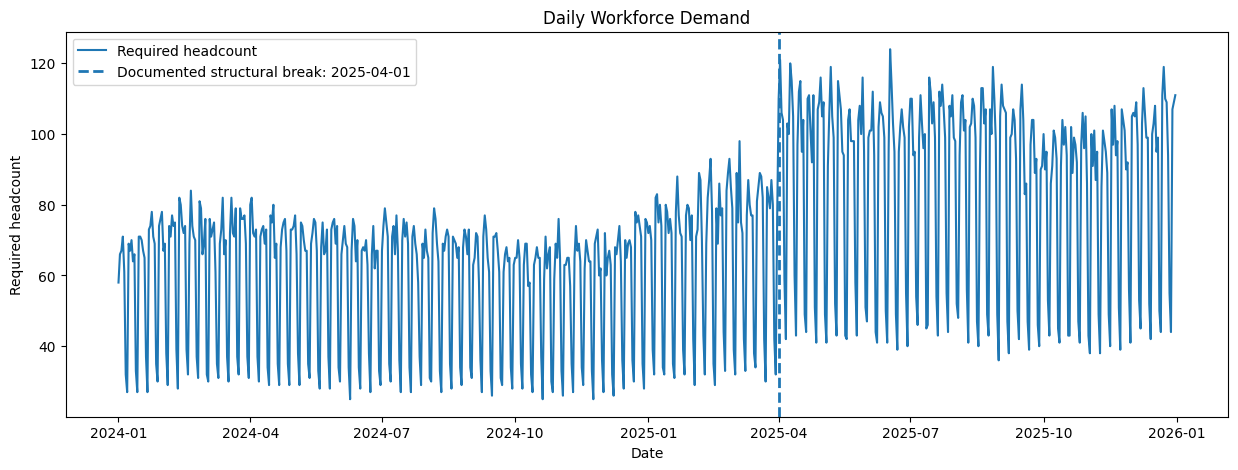

In [58]:
DATA_PATH = fetch("data/workforce_demand.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
).sort_values("date").reset_index(drop=True)

workforce = (
    df.set_index("date")["required_headcount"]
      .asfreq("D")
      .astype(float)
)

# Basic integrity checks
assert workforce.index.is_monotonic_increasing
assert workforce.index.is_unique
assert workforce.isna().sum() == 0
assert (workforce >= 0).all()

print(f"Rows: {len(workforce)}")
print(f"Date range: {workforce.index.min().date()} to {workforce.index.max().date()}")
print(f"Missing observations: {workforce.isna().sum()}")
print(f"Minimum headcount: {workforce.min():.0f}")
print(f"Maximum headcount: {workforce.max():.0f}")
print(f"Zero observations: {(workforce == 0).sum()}")

display(df.head())

plt.figure(figsize=(15, 5))
plt.plot(workforce.index, workforce.values, label="Required headcount")
plt.axvline(
    BREAK_DATE,
    linestyle="--",
    linewidth=2,
    label="Documented structural break: 2025-04-01"
)

plt.title("Daily Workforce Demand")
plt.xlabel("Date")
plt.ylabel("Required headcount")
plt.legend()
plt.show()

### Initial observations

The dataset contains **731 consecutive daily observations**, from 2024-01-01 to 2025-12-31, with no missing values.

The raw series immediately shows a repeating within-week pattern: workforce requirements are substantially lower on the weekend than on weekdays. This motivates the use of a weekly seasonal period of 7.

A noticeable upward level shift is also visible around 2025-04-01.

Importantly, the break date will **not** be used as a forecasting feature. It is retained only to annotate diagnostics and to examine whether the backtesting design reveals performance degradation around the regime change.

Because the target contains no zeros, percentage-based metrics are mathematically possible. However, this project reports **MASE and WAPE** alongside MAE and RMSE because they provide more useful scale-free interpretations and are consistent with the course evaluation framework.

# 1. Time Series Structure and Diagnostics

This section examines the internal structure of the workforce-demand series before selecting a forecasting model.

The analysis includes:

- STL decomposition into trend, seasonal, and residual components,
- ACF and PACF analysis,
- an Augmented Dickey-Fuller stationarity test,
- and differencing when required.

The goal is not only to produce diagnostic plots, but to use them to justify subsequent modeling choices.

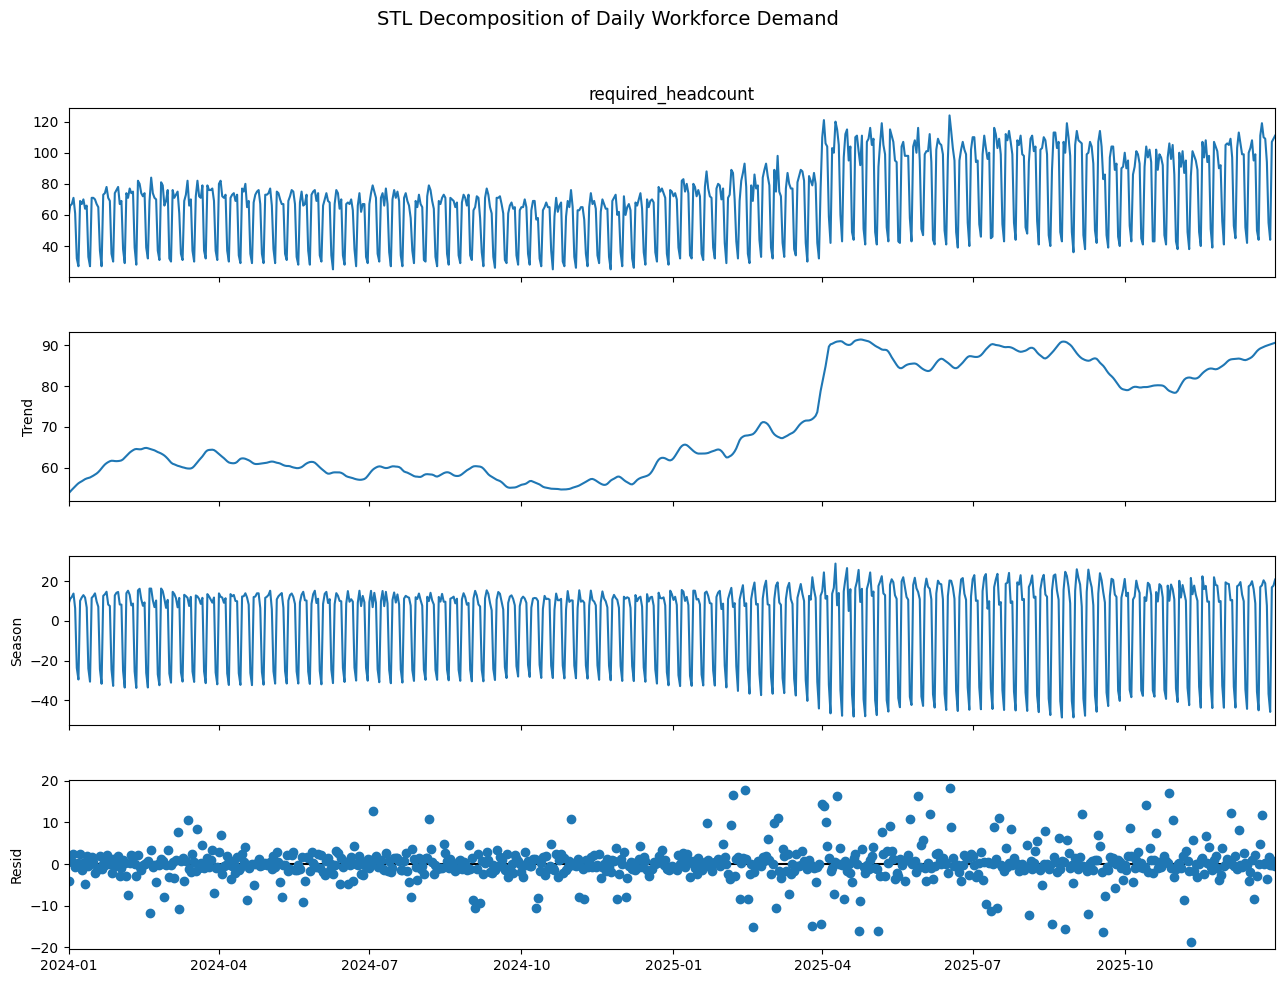

28-day mean before break: 68.79
28-day mean after break:  90.29
Observed local level increase: 31.3%

STL residuals around the break:


,STL residual
date,
2025-03-27,-1.009724
2025-03-28,-4.253287
2025-03-29,-0.826350
2025-03-30,0.003747
2025-03-31,-14.417266
2025-04-01,14.356706
2025-04-02,13.877637
2025-04-03,10.000290
2025-04-04,4.253781


In [59]:
stl = STL(
    workforce,
    period=SEASONAL_PERIOD,
    robust=True
)

stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle(
    "STL Decomposition of Daily Workforce Demand",
    y=1.02,
    fontsize=14
)
plt.show()


# Quantify the local change around the documented break
pre_break_28 = workforce.loc[
    BREAK_DATE - pd.Timedelta(days=28):
    BREAK_DATE - pd.Timedelta(days=1)
]

post_break_28 = workforce.loc[
    BREAK_DATE:
    BREAK_DATE + pd.Timedelta(days=27)
]

pre_mean = pre_break_28.mean()
post_mean = post_break_28.mean()
local_change_pct = (post_mean / pre_mean - 1) * 100

print(f"28-day mean before break: {pre_mean:.2f}")
print(f"28-day mean after break:  {post_mean:.2f}")
print(f"Observed local level increase: {local_change_pct:.1f}%")

print("\nSTL residuals around the break:")
display(
    stl_result.resid.loc[
        "2025-03-27":"2025-04-10"
    ].to_frame("STL residual")
)

**Decomposition interpretation**

The STL decomposition confirms a **strong weekly seasonal component**, consistent with the visibly lower staffing requirements on weekends.

The trend component changes much more slowly than the observed series. Around 2025-04-01, the observed level increases abruptly, while STL initially smooths through the change. The residual component therefore contains unusually large errors around the break.

The 28-day average immediately before the break is approximately **68.8 employees**, compared with approximately **90.3 employees** over the following 28 days. This is a substantial level increase.

This is important for model evaluation: a standard seasonal forecasting model may describe the recurring weekly pattern well while still failing temporarily when an unexpected regime change occurs.

Therefore, the structural break should be evaluated explicitly during walk-forward backtesting rather than relying only on a recent train/test split.

## ACF and PACF Before and After Differencing

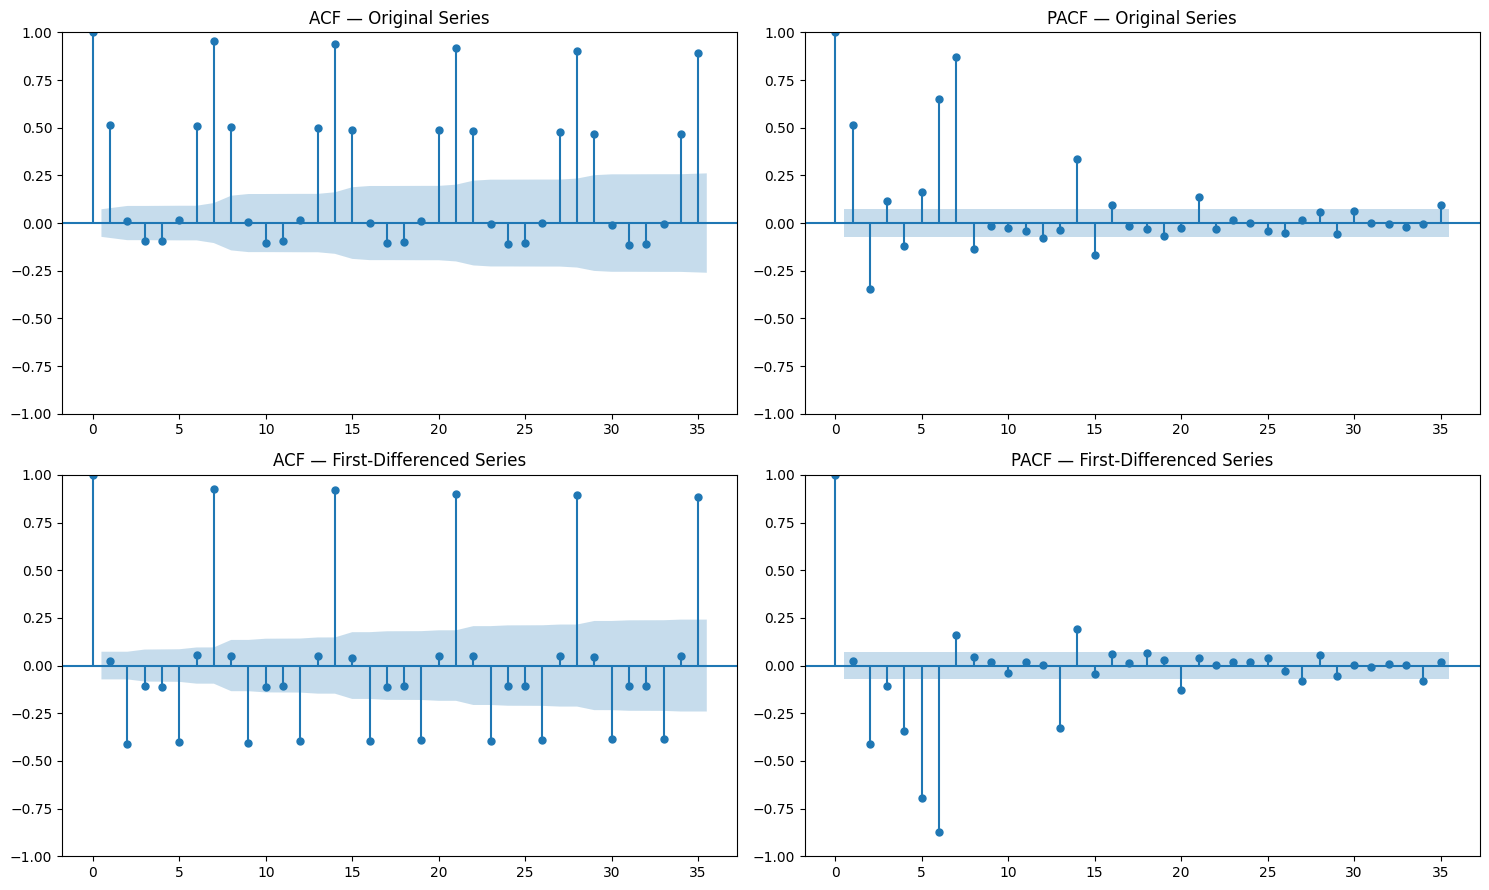

In [60]:
first_difference = workforce.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

plot_acf(
    workforce,
    lags=35,
    ax=axes[0, 0]
)
axes[0, 0].set_title("ACF — Original Series")

plot_pacf(
    workforce,
    lags=35,
    method="ywm",
    ax=axes[0, 1]
)
axes[0, 1].set_title("PACF — Original Series")

plot_acf(
    first_difference,
    lags=35,
    ax=axes[1, 0]
)
axes[1, 0].set_title("ACF — First-Differenced Series")

plot_pacf(
    first_difference,
    lags=35,
    method="ywm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("PACF — First-Differenced Series")

plt.tight_layout()
plt.show()

## Inspect Important ACF Values Numerically

In [61]:
from statsmodels.tsa.stattools import acf, pacf

raw_acf = acf(
    workforce,
    nlags=14,
    fft=True
)

diff_acf = acf(
    first_difference,
    nlags=14,
    fft=True
)

raw_pacf = pacf(
    workforce,
    nlags=14,
    method="ywm"
)

acf_summary = pd.DataFrame({
    "lag": range(1, 15),
    "raw_acf": raw_acf[1:15],
    "first_difference_acf": diff_acf[1:15],
    "raw_pacf": raw_pacf[1:15]
})

display(acf_summary.round(3))

,lag,raw_acf,first_difference_acf,raw_pacf
0,1,0.516,0.021,0.516
1,2,0.012,-0.411,-0.347
2,3,-0.096,-0.109,0.115
3,4,-0.094,-0.113,-0.122
4,5,0.017,-0.402,0.161
5,6,0.511,0.053,0.650
6,7,0.953,0.926,0.868
7,8,0.504,0.051,-0.135
8,9,0.004,-0.407,-0.017
9,10,-0.102,-0.111,-0.024


**ACF and PACF interpretation**

The autocorrelation diagnostics provide strong evidence of weekly dependence.

In the original series:

- ACF at lag 7 is approximately **0.95**.
- ACF at lag 14 is also approximately **0.94**.

The recurrence of large autocorrelation at multiples of 7 confirms that observations separated by complete weeks are strongly related.

The PACF also shows a substantial direct relationship around the weekly lag, supporting the interpretation that weekly history contains useful predictive information.

After first differencing, the short-term level behavior changes substantially, but the ACF still contains very large spikes at lags 7 and 14. Therefore, differencing the level does **not** remove the weekly seasonal structure.

This suggests two separate characteristics:

1. the level of the raw series is non-stationary and may require differencing for stationary-model diagnostics;
2. weekly seasonality remains a major source of predictable structure and should be modeled explicitly.

## ADF Stationarity Test

In [62]:
def adf_report(series, name):
    result = adfuller(
        series.dropna(),
        autolag="AIC"
    )

    report = {
        "Series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "lags used": result[2],
        "observations": result[3]
    }

    return report


adf_results = pd.DataFrame([
    adf_report(
        workforce,
        "Original series"
    ),
    adf_report(
        first_difference,
        "First difference"
    )
])

display(adf_results.round(6))

,Series,ADF statistic,p-value,lags used,observations
0,Original series,-0.563394,0.879041,20,710
1,First difference,-8.210925,0.000000,19,710


In [63]:
# Additional stationarity checks

seasonal_diff = workforce.diff(SEASONAL_PERIOD).dropna()
both_diff = workforce.diff(SEASONAL_PERIOD).diff().dropna()

pre_break_series = workforce.loc[
    workforce.index < BREAK_DATE
]

display(
    pd.DataFrame([
        adf_report(
            workforce,
            "Original series"
        ),
        adf_report(
            first_difference,
            "First difference (d=1)"
        ),
        adf_report(
            seasonal_diff,
            "Seasonal difference (D=1, s=7)"
        ),
        adf_report(
            both_diff,
            "Seasonal + first difference"
        ),
        adf_report(
            pre_break_series,
            "Pre-break original series"
        )
    ]).round(6)
)


# Examine whether the weekly seasonal effect is additive or multiplicative

seasonality_frame = pd.DataFrame({
    "y": workforce.values,

    "regime": np.where(
        workforce.index < BREAK_DATE,
        "pre-break",
        "post-break"
    ),

    "day_type": np.where(
        workforce.index.dayofweek >= 5,
        "weekend mean",
        "weekday mean"
    )
}, index=workforce.index)


seasonal_shape = (
    seasonality_frame
    .groupby(
        ["regime", "day_type"]
    )["y"]
    .mean()
    .unstack()
)

seasonal_shape["absolute gap"] = (
    seasonal_shape["weekday mean"]
    - seasonal_shape["weekend mean"]
)

seasonal_shape["weekend / weekday"] = (
    seasonal_shape["weekend mean"]
    / seasonal_shape["weekday mean"]
)

display(
    seasonal_shape.round(3)
)

,Series,ADF statistic,p-value,lags used,observations
0,Original series,-0.563394,0.879041,20,710
1,First difference (d=1),-8.210925,0.000000,19,710
2,"Seasonal difference (D=1, s=7)",-6.327194,0.000000,20,703
3,Seasonal + first difference,-9.554564,0.000000,20,702
4,Pre-break original series,-0.603684,0.870147,13,442


day_type,weekday mean,weekend mean,absolute gap,weekend / weekday
regime,,,,
post-break,102.574,46.141,56.433,0.450
pre-break,71.782,32.423,39.359,0.452


### Stationarity and seasonal-form conclusion

The original workforce series has an ADF p-value of approximately **0.879**.

At the 5% significance level:

$$
p > 0.05
$$

I therefore fail to reject the null hypothesis of a unit root, so the original series should be treated as non-stationary.

After first-order differencing,

$$
y'_t = y_t - y_{t-1},
$$

the ADF p-value falls effectively to zero. A seasonal difference at lag 7 also produces a p-value well below 0.05, and combining regular and seasonal differencing remains stationary.

The original **pre-break** portion of the series also has an ADF p-value of approximately **0.87**. Therefore, the stationarity problem cannot be attributed only to the structural break on 2025-04-01.

The ACF additionally shows very strong dependence at weekly lags. This means that even after addressing the changing level, weekly seasonal structure still needs to be modeled explicitly.

The weekday/weekend comparison also informs the form of that seasonality. Before the structural break, the weekend-to-weekday mean ratio is approximately **0.452**; after the break it remains approximately **0.450**. In contrast, the absolute weekday-weekend gap increases from roughly **39** employees to roughly **56** employees as the overall level rises.

A nearly stable proportional effect combined with a growing absolute seasonal gap is more consistent with **multiplicative seasonality** than with additive seasonality.

For this reason, the classical-model section does not assume an additive form in advance. Additive and multiplicative exponential-smoothing specifications are compared explicitly using information criteria.

# 2. Classical Forecasting Models

This section evaluates two classical forecasting approaches from the course:

1. **Exponential Smoothing**
2. **SARIMAX**

The diagnostic analysis established:

- strong weekly seasonality with period 7,
- non-stationarity in the original level,
- and evidence that the seasonal effect behaves more like a proportional, or multiplicative, effect than a constant additive difference.

Rather than choosing a Holt-Winters configuration arbitrarily, several exponential-smoothing specifications are compared using **AIC and BIC**.

Several SARIMAX orders are also fitted and compared using AIC and BIC. This provides a data-driven rationale for the classical-model configuration rather than relying on a single guessed order.

A final 60-day holdout is retained for model inspection, while the later walk-forward backtest provides the more reliable model comparison across multiple historical periods.

## Final 60-Day Holdout

In [64]:
train = workforce.iloc[:-HOLDOUT_HORIZON].copy()
test = workforce.iloc[-HOLDOUT_HORIZON:].copy()

assert train.index.max() < test.index.min()
assert len(test) == HOLDOUT_HORIZON

print(
    "Training period:",
    train.index.min().date(),
    "to",
    train.index.max().date()
)

print(
    "Holdout period:",
    test.index.min().date(),
    "to",
    test.index.max().date()
)

print("Training observations:", len(train))
print("Holdout observations:", len(test))

Training period: 2024-01-01 to 2025-11-01
Holdout period: 2025-11-02 to 2025-12-31
Training observations: 671
Holdout observations: 60


## Fit Holt-Winters

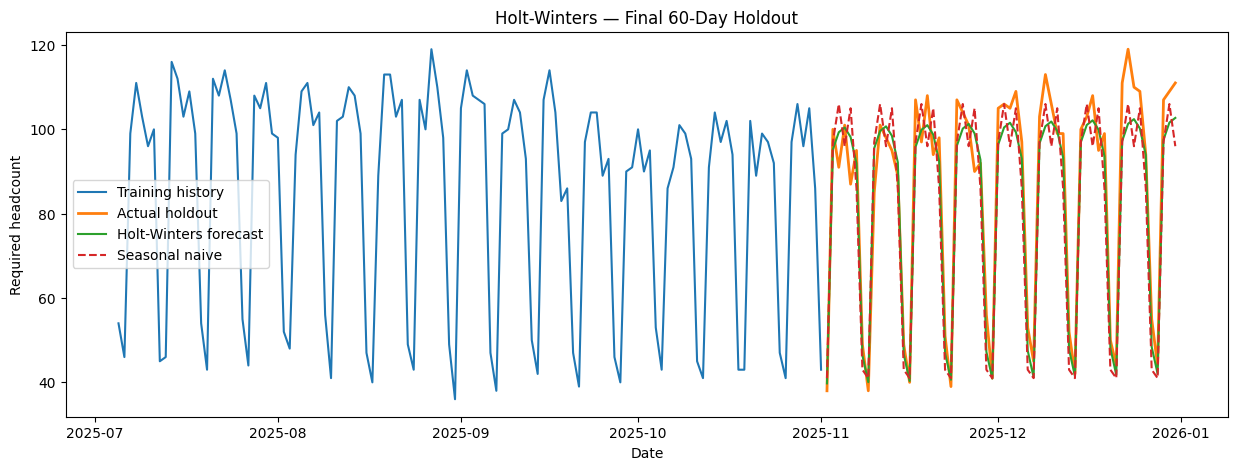

In [65]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated"
)

hw_fit = hw_model.fit(
    optimized=True
)

best_hw_forecast = np.asarray(
    hw_fit.forecast(HOLDOUT_HORIZON),
    dtype=float
)

seasonal_naive = seasonal_naive_forecast(
    train.values,
    horizon=HOLDOUT_HORIZON,
    period=SEASONAL_PERIOD
)


plt.figure(figsize=(15, 5))

plt.plot(
    train.index[-120:],
    train.iloc[-120:],
    label="Training history"
)

plt.plot(
    test.index,
    test.values,
    label="Actual holdout",
    linewidth=2
)

plt.plot(
    test.index,
    best_hw_forecast,
    label="Holt-Winters forecast"
)

plt.plot(
    test.index,
    seasonal_naive,
    label="Seasonal naive",
    linestyle="--"
)

plt.title("Holt-Winters — Final 60-Day Holdout")
plt.xlabel("Date")
plt.ylabel("Required headcount")
plt.legend()
plt.show()

## Classical Model Metrics

In [66]:
classical_scores = pd.DataFrame([
    {
        "model": "Holt-Winters (additive benchmark)",
        "MAE": mae(test.values, best_hw_forecast),
        "RMSE": rmse(test.values, best_hw_forecast),
        "WAPE (%)": wape(test.values, best_hw_forecast),
        "MASE": mase(
            test.values,
            best_hw_forecast,
            train.values,
            seasonal_period=SEASONAL_PERIOD
        )
    },
    {
        "model": "Seasonal naive",
        "MAE": mae(test.values, seasonal_naive),
        "RMSE": rmse(test.values, seasonal_naive),
        "WAPE (%)": wape(test.values, seasonal_naive),
        "MASE": mase(
            test.values,
            seasonal_naive,
            train.values,
            seasonal_period=SEASONAL_PERIOD
        )
    }
]).set_index("model")

display(classical_scores.round(3))

,MAE,RMSE,WAPE (%),MASE
model,,,,
Holt-Winters (additive benchmark),5.168,6.416,6.029,1.080
Seasonal naive,7.683,8.889,8.964,1.606


## Ljung-Box Residual Diagnostic

,lb_stat,lb_pvalue
7,15.6895,0.0281
14,24.8542,0.0360
21,34.3317,0.0334


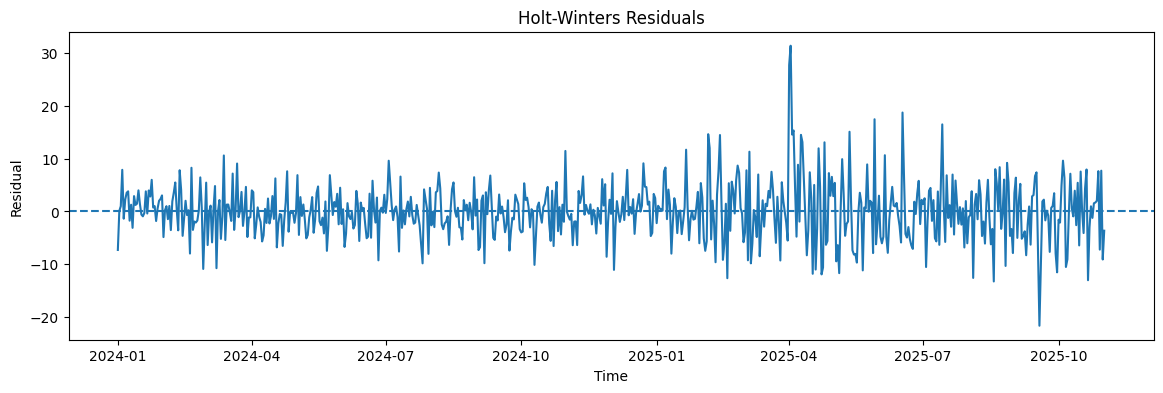

In [67]:
hw_residuals = pd.Series(
    hw_fit.resid
).dropna()

ljung_box = acorr_ljungbox(
    hw_residuals,
    lags=[7, 14, 21],
    return_df=True
)

display(ljung_box.round(4))

plt.figure(figsize=(14, 4))
plt.plot(hw_residuals)
plt.axhline(0, linestyle="--")
plt.title("Holt-Winters Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

In [68]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ---------------------------------------------------------
# A. Exponential Smoothing candidate selection
# ---------------------------------------------------------

hw_specs = [
    ("add", "add", False),
    ("add", "add", True),
    (None,  "add", False),
    ("add", "mul", False),
    ("mul", "mul", False),
    (None,  "mul", False),
]

hw_rows = []

for trend, seasonal, damped in hw_specs:

    fit = ExponentialSmoothing(
        train,
        trend=trend,
        seasonal=seasonal,
        damped_trend=damped,
        seasonal_periods=SEASONAL_PERIOD,
        initialization_method="estimated"
    ).fit()

    forecast = np.asarray(
        fit.forecast(HOLDOUT_HORIZON),
        dtype=float
    )

    hw_rows.append({
        "trend": trend,
        "seasonal": seasonal,
        "damped": damped,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "holdout MAE": mae(
            test.values,
            forecast
        ),
        "holdout WAPE (%)": wape(
            test.values,
            forecast
        )
    })


hw_table = (
    pd.DataFrame(hw_rows)
    .sort_values("AIC")
    .reset_index(drop=True)
)

display(
    hw_table.round(3)
)


# Select the AIC-best exponential-smoothing configuration

best_hw = hw_table.iloc[0]

BEST_HW_TREND = (
    None
    if pd.isna(best_hw["trend"])
    else best_hw["trend"]
)

BEST_HW_SEASONAL = best_hw["seasonal"]
BEST_HW_DAMPED = bool(best_hw["damped"])


best_hw_fit = ExponentialSmoothing(
    train,
    trend=BEST_HW_TREND,
    seasonal=BEST_HW_SEASONAL,
    damped_trend=BEST_HW_DAMPED,
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated"
).fit()


best_hw_forecast = np.asarray(
    best_hw_fit.forecast(
        HOLDOUT_HORIZON
    ),
    dtype=float
)


print(
    "Selected exponential-smoothing specification:",
    f"trend={BEST_HW_TREND},",
    f"seasonal={BEST_HW_SEASONAL},",
    f"damped={BEST_HW_DAMPED}"
)

print(
    f"Selected ES holdout MAE = "
    f"{mae(test.values, best_hw_forecast):.3f}"
)

print(
    f"Selected ES holdout WAPE = "
    f"{wape(test.values, best_hw_forecast):.3f}%"
)


print("\nLjung-Box — selected exponential-smoothing model")

display(
    acorr_ljungbox(
        pd.Series(
            best_hw_fit.resid
        ).dropna(),
        lags=[7, 14, 21],
        return_df=True
    ).round(4)
)


# ---------------------------------------------------------
# B. SARIMAX candidate selection
# ---------------------------------------------------------

sarimax_rows = []

nonseasonal_candidates = [
    (1, 0, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 2)
]

seasonal_candidates = [
    (0, 1, 1),
    (1, 1, 1)
]


for (p, d, q), (P, D, Q) in itertools.product(
    nonseasonal_candidates,
    seasonal_candidates
):

    try:

        result = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(
                P,
                D,
                Q,
                SEASONAL_PERIOD
            ),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(
            disp=False,
            maxiter=200
        )

        forecast = np.asarray(
            result.forecast(
                HOLDOUT_HORIZON
            ),
            dtype=float
        )

        sarimax_rows.append({
            "order": (p, d, q),
            "seasonal_order": (
                P,
                D,
                Q,
                SEASONAL_PERIOD
            ),
            "AIC": result.aic,
            "BIC": result.bic,
            "holdout MAE": mae(
                test.values,
                forecast
            ),
            "holdout WAPE (%)": wape(
                test.values,
                forecast
            )
        })

    except Exception as exc:

        print(
            "Skipped:",
            (p, d, q),
            (P, D, Q),
            exc
        )


sarimax_table = pd.DataFrame(
    sarimax_rows
)

sarimax_by_aic = (
    sarimax_table
    .sort_values("AIC")
    .reset_index(drop=True)
)

sarimax_by_bic = (
    sarimax_table
    .sort_values("BIC")
    .reset_index(drop=True)
)


print("SARIMAX candidates sorted by AIC:")
display(
    sarimax_by_aic.round(3)
)

print("AIC-best SARIMAX:")
display(
    sarimax_by_aic.head(1)
)

print("BIC-best SARIMAX:")
display(
    sarimax_by_bic.head(1)
)


# Use the AIC-selected SARIMAX for residual inspection

best_sarimax_row = sarimax_by_aic.iloc[0]

best_sarimax = SARIMAX(
    train,
    order=best_sarimax_row["order"],
    seasonal_order=best_sarimax_row[
        "seasonal_order"
    ],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False,
    maxiter=200
)


burn_in = (
    best_sarimax_row["order"][1]
    + best_sarimax_row[
        "seasonal_order"
    ][1] * SEASONAL_PERIOD
)

sarimax_residuals = (
    best_sarimax.resid
    .iloc[burn_in:]
)


print(
    "Ljung-Box — AIC-selected SARIMAX"
)

display(
    acorr_ljungbox(
        sarimax_residuals,
        lags=[7, 14, 21],
        return_df=True
    ).round(4)
)


sarimax_forecast = np.asarray(
    best_sarimax.forecast(
        HOLDOUT_HORIZON
    ),
    dtype=float
)

print(
    f"SARIMAX "
    f"{best_sarimax_row['order']} x "
    f"{best_sarimax_row['seasonal_order']} | "
    f"MAE = "
    f"{mae(test.values, sarimax_forecast):.3f} | "
    f"WAPE = "
    f"{wape(test.values, sarimax_forecast):.3f}%"
)

,trend,seasonal,damped,AIC,BIC,holdout MAE,holdout WAPE (%)
0,None,mul,False,2171.914,2212.493,6.311,7.363
1,mul,mul,False,2175.320,2224.917,5.263,6.140
2,add,mul,False,2175.976,2225.572,7.117,8.303
3,None,add,False,2266.301,2306.880,6.202,7.235
4,add,add,True,2268.831,2322.936,6.185,7.215
5,add,add,False,2269.027,2318.623,5.168,6.029


Selected exponential-smoothing specification: trend=None, seasonal=mul, damped=False
Selected ES holdout MAE = 6.311
Selected ES holdout WAPE = 7.363%

Ljung-Box — selected exponential-smoothing model


,lb_stat,lb_pvalue
7,9.0116,0.2518
14,14.3111,0.4268
21,29.1075,0.1114


SARIMAX candidates sorted by AIC:


,order,seasonal_order,AIC,BIC,holdout MAE,holdout WAPE (%)
0,"(2, 1, 2)","(0, 1, 1, 7)",4066.591,4093.480,7.574,8.836
1,"(2, 1, 2)","(1, 1, 1, 7)",4068.577,4099.948,7.574,8.836
2,"(1, 1, 1)","(0, 1, 1, 7)",4071.256,4089.189,7.738,9.028
3,"(1, 1, 1)","(1, 1, 1, 7)",4074.450,4096.865,7.732,9.020
4,"(0, 1, 1)","(0, 1, 1, 7)",4075.939,4089.388,7.638,8.911
5,"(0, 1, 1)","(1, 1, 1, 7)",4077.932,4095.864,7.638,8.911
6,"(1, 0, 0)","(0, 1, 1, 7)",4145.846,4159.305,6.435,7.507
7,"(1, 0, 0)","(1, 1, 1, 7)",4147.828,4165.773,6.433,7.505


...

BIC-best SARIMAX:


,order,seasonal_order,AIC,BIC,holdout MAE,holdout WAPE (%)
0,"(1, 1, 1)","(0, 1, 1, 7)",4071.256336,4089.188766,7.738211,9.027663


Ljung-Box — AIC-selected SARIMAX


,lb_stat,lb_pvalue
7,7.0034,0.4285
14,14.9790,0.3796
21,25.2546,0.2363


SARIMAX (2, 1, 2) x (0, 1, 1, 7) | MAE = 7.574 | WAPE = 8.836%


**Information-criterion interpretation**

AIC and BIC are used here to compare alternative configurations **within the same model family**.

The AIC of an exponential-smoothing model is therefore compared with the AIC of other exponential-smoothing specifications, while SARIMAX orders are compared with other SARIMAX orders.

I do not use the raw AIC value of an exponential-smoothing model to declare it better than a SARIMAX model, because the likelihood constructions are not directly equivalent across those families.

Cross-family forecasting performance is evaluated later using the common walk-forward backtest.

### Classical-model interpretation

The initial additive Holt-Winters specification performs reasonably well on the final 60-day holdout, with MAE approximately **5.17** and WAPE approximately **6.03%**.

However, its Ljung-Box p-values at lags 7, 14, and 21 are approximately **0.028, 0.036, and 0.033**, all below 0.05. This indicates that statistically significant autocorrelation remains in the additive model's residuals.

The candidate comparison changes the conclusion.

The AIC-best exponential-smoothing specification uses **multiplicative weekly seasonality with no explicit trend term**. Its AIC is approximately **2172**, compared with approximately **2269** for the original additive-trend/additive-seasonality specification.

The selected multiplicative model also produces Ljung-Box p-values of approximately **0.25, 0.43, and 0.11** at lags 7, 14, and 21. I therefore fail to reject the no-autocorrelation null at these tested lags. This supports the earlier diagnostic evidence that the weekly seasonal effect is better represented proportionally than additively.

Interestingly, the final 60-day holdout alone favors the original additive model: the selected multiplicative specification has holdout MAE of approximately **6.31** and WAPE of approximately **7.36%**.

This disagreement is useful rather than problematic. It demonstrates why one holdout should not determine the model decision. The later walk-forward backtest evaluates whether the conclusion survives across many historical forecast origins.

SARIMAX is also fitted rather than merely discussed. Multiple non-seasonal and seasonal orders are compared using AIC and BIC, and the selected SARIMAX model is subjected to the same Ljung-Box residual diagnostic.

The final model-family decision will therefore be based primarily on repeated out-of-sample backtesting rather than on a single holdout or information criterion alone.

# 3. Machine-Learning Forecasting with LightGBM

The second forecasting family is LightGBM.

Unlike Holt-Winters, a tree-based model does not automatically know what a time series is. Temporal structure must therefore be represented explicitly using features.

The feature set contains three required feature types:

### Lag features
- lag 1
- lag 7
- lag 14
- lag 28

### Rolling features
- 7-day rolling mean
- 7-day rolling standard deviation
- 28-day rolling mean

### Calendar features
- day of week
- month
- sine/cosine encoding of day of year

The lags are chosen to represent recent behavior and weekly recurrence.

The rolling windows summarize recent demand level and variability.

Calendar variables allow the model to learn systematic differences across weekdays and broader annual timing.

##Leakage prevention

Time-series feature engineering is only valid if every feature used for a forecast would actually be available at forecast time.

Two safeguards are used here:

1. Rolling features are calculated from `y.shift(1)` rather than directly from the target. This prevents the current day's true target from entering its own predictors.

2. The 60-day holdout is forecast **recursively**. After the first test date, the actual future target values are never inserted into lag or rolling features. Instead, the model feeds its own earlier predictions back into the forecasting history.

This is essential for a realistic multi-step forecast. Building all lag features from the complete dataset before splitting would leak holdout targets into later predictions and would produce an unrealistically optimistic result.

In [69]:
LAGS = [1, 7, 14, 28]
ROLLING_WINDOWS = [7, 28]

FEATURE_COLUMNS = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll_mean_7",
    "roll_std_7",
    "roll_mean_28",
    "dayofweek",
    "month",
    "doy_sin",
    "doy_cos"
]


def make_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame({
        "y": series.astype(float)
    })

    # Lag features
    for lag in LAGS:
        features[f"lag_{lag}"] = features["y"].shift(lag)

    # Rolling features use only past values
    shifted_target = features["y"].shift(1)

    features["roll_mean_7"] = (
        shifted_target
        .rolling(7)
        .mean()
    )

    features["roll_std_7"] = (
        shifted_target
        .rolling(7)
        .std()
    )

    features["roll_mean_28"] = (
        shifted_target
        .rolling(28)
        .mean()
    )

    # Calendar features
    dates = features.index

    features["dayofweek"] = dates.dayofweek
    features["month"] = dates.month

    day_of_year = dates.dayofyear

    features["doy_sin"] = np.sin(
        2 * np.pi * day_of_year / 365.25
    )

    features["doy_cos"] = np.cos(
        2 * np.pi * day_of_year / 365.25
    )

    return features


training_features = (
    make_features(train)
    .dropna()
)

print("Training feature matrix:", training_features.shape)

display(
    training_features[
        ["y"] + FEATURE_COLUMNS
    ].tail()
)

Training feature matrix: (643, 12)


,y,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_28,dayofweek,month,doy_sin,doy_cos
date,,,,,,,,,,,,
2025-10-28,106.0,97.0,89.0,104.0,91.0,80.285714,25.077974,80.928571,1,10,-0.893579,0.448906
2025-10-29,96.0,106.0,99.0,97.0,100.0,82.714286,26.824829,81.464286,2,10,-0.885725,0.464210
2025-10-30,105.0,96.0,97.0,102.0,90.0,82.285714,26.543764,81.321429,3,10,-0.877609,0.479378
2025-10-31,86.0,105.0,92.0,94.0,95.0,83.428571,27.439978,81.857143,4,10,-0.869233,0.494403
2025-11-01,43.0,86.0,47.0,43.0,53.0,82.571429,27.220440,81.535714,5,11,-0.860600,0.509282


## Fit Point-Forecast LightGBM

In [70]:
X_train_lgb = training_features[FEATURE_COLUMNS]
y_train_lgb = training_features["y"]

lgb_point_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15,
    random_state=RNG_SEED,
    verbosity=-1
)

lgb_point_model.fit(
    X_train_lgb,
    y_train_lgb
)

print("LightGBM fitted.")

LightGBM fitted.


## Recursive Multi-Step Forecast

In [71]:
def recursive_lgb_forecast(
    model,
    history: pd.Series,
    future_index: pd.DatetimeIndex
):
    """
    Forecast one day at a time.

    Future actual targets are never used.
    Previous predictions are fed back into the history when needed.
    """

    recursive_history = history.copy().astype(float)

    original_history_end = recursive_history.index.max()

    predictions = []
    lineage_records = []

    for step, forecast_date in enumerate(future_index):

        # Add an empty target row for the date being forecast
        recursive_history.loc[forecast_date] = np.nan

        # Confirm the latest known non-missing target is strictly in the past
        latest_known_date = recursive_history.dropna().index.max()

        assert latest_known_date < forecast_date

        feature_row = (
            make_features(recursive_history)
            .loc[[forecast_date], FEATURE_COLUMNS]
        )

        assert feature_row.notna().all().all()

        prediction = float(
            model.predict(feature_row)[0]
        )

        # Count how many lag variables now originate from earlier forecasts
        predicted_lag_count = sum(
            forecast_date - pd.Timedelta(days=lag) > original_history_end
            for lag in LAGS
        )

        lineage_records.append({
            "forecast_date": forecast_date,
            "forecast_step": step + 1,
            "predicted_lag_features": predicted_lag_count
        })

        # Only after prediction do we place the prediction in history
        recursive_history.loc[forecast_date] = prediction

        predictions.append(prediction)

    return (
        np.asarray(predictions, dtype=float),
        pd.DataFrame(lineage_records)
    )


lgb_forecast, lineage = recursive_lgb_forecast(
    lgb_point_model,
    train,
    test.index
)

assert len(lgb_forecast) == len(test)

display(
    lineage.iloc[
        [0, 6, 7, 13, 27, 59]
    ]
)

,forecast_date,forecast_step,predicted_lag_features
0,2025-11-02,1,0
6,2025-11-08,7,1
7,2025-11-09,8,2
13,2025-11-15,14,2
27,2025-11-29,28,3
59,2025-12-31,60,4


**Recursive feature lineage**

The lineage table demonstrates why recursive forecasting is necessary.

At the beginning of the forecast horizon, lag variables still come from observed training history.

As the horizon advances, an increasing number of lag values refer to dates after the end of the original training sample. Those values therefore come from earlier **model predictions**, not from the holdout's true targets.

This reproduces the information conditions that would exist in a real 60-day forecast and prevents target leakage.

## ML Holdout Performance

,MAE,RMSE,WAPE (%),MASE
LightGBM recursive,5.515,6.595,6.434,1.153


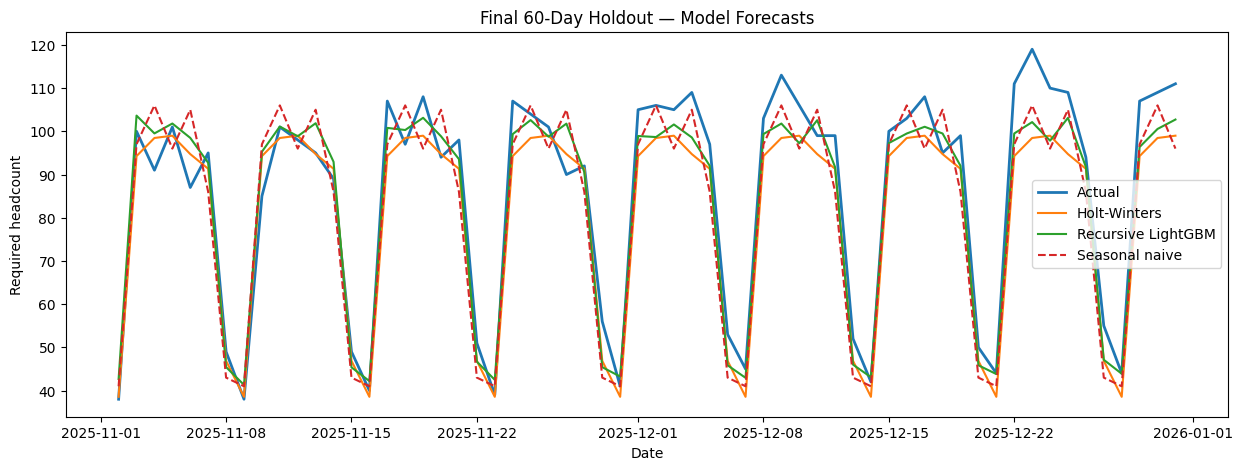

In [72]:
lgb_scores = {
    "MAE": mae(
        test.values,
        lgb_forecast
    ),
    "RMSE": rmse(
        test.values,
        lgb_forecast
    ),
    "WAPE (%)": wape(
        test.values,
        lgb_forecast
    ),
    "MASE": mase(
        test.values,
        lgb_forecast,
        train.values,
        seasonal_period=SEASONAL_PERIOD
    )
}

display(
    pd.DataFrame(
        [lgb_scores],
        index=["LightGBM recursive"]
    ).round(3)
)


plt.figure(figsize=(15, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    best_hw_forecast,
    label="Holt-Winters"
)

plt.plot(
    test.index,
    lgb_forecast,
    label="Recursive LightGBM"
)

plt.plot(
    test.index,
    seasonal_naive,
    label="Seasonal naive",
    linestyle="--"
)

plt.title("Final 60-Day Holdout — Model Forecasts")
plt.xlabel("Date")
plt.ylabel("Required headcount")
plt.legend()
plt.show()

## LightGBM Feature Importance

,gain share (%)
dayofweek,61.78
roll_mean_28,23.98
lag_7,6.01
roll_mean_7,2.48
lag_14,1.50
lag_28,1.17
lag_1,1.08
doy_sin,0.86
doy_cos,0.52
month,0.35


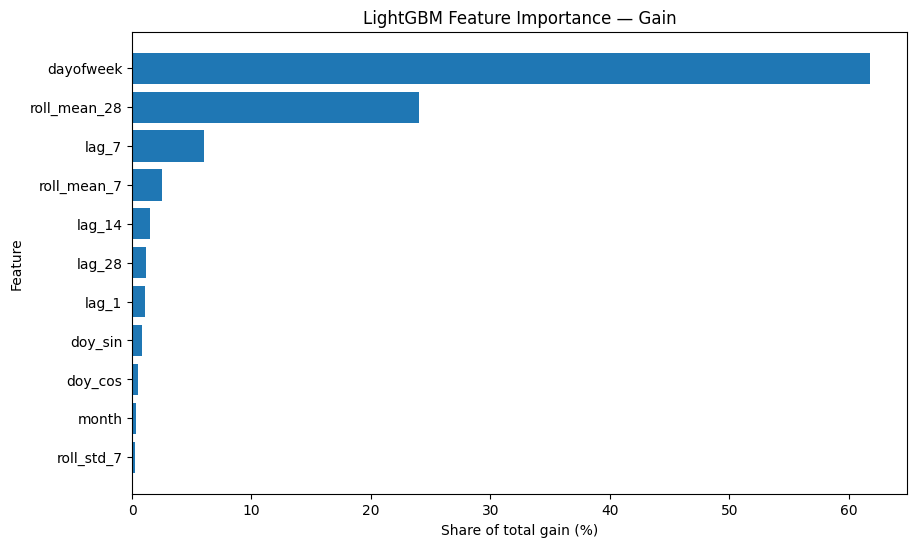

In [73]:
gain_importance = pd.Series(
    lgb_point_model
    .booster_
    .feature_importance(
        importance_type="gain"
    ),
    index=FEATURE_COLUMNS
)

gain_share = (
    gain_importance
    / gain_importance.sum()
    * 100
).sort_values(
    ascending=False
)

gain_table = (
    gain_share
    .round(2)
    .rename(
        "gain share (%)"
    )
    .to_frame()
)

display(
    gain_table
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(
    gain_table.index[::-1],
    gain_table[
        "gain share (%)"
    ][::-1]
)

plt.title(
    "LightGBM Feature Importance — Gain"
)

plt.xlabel(
    "Share of total gain (%)"
)

plt.ylabel(
    "Feature"
)

plt.show()

### LightGBM interpretation

The recursive LightGBM forecast produces approximately:

- **MAE ≈ 5.52**
- **RMSE ≈ 6.59**
- **WAPE ≈ 6.43%**
- **MASE ≈ 1.15**

Using gain-based feature importance changes the interpretation compared with simply counting the number of tree splits.

The dominant feature is **day of week**, accounting for approximately **62% of total gain**, followed by the 28-day rolling mean at approximately **24%**. The weekly lag also contributes useful signal, while month and annual sine/cosine terms contribute relatively little on this dataset.

This is consistent with the earlier diagnostics: the strongest predictable structure in the series is the recurring weekly staffing pattern.

The final 60-day holdout actually favors LightGBM over the AIC-selected multiplicative exponential-smoothing specification. LightGBM has WAPE of approximately **6.43%**, compared with approximately **7.36%** for the selected exponential-smoothing model.

However, this is only one post-break holdout. The model decision is therefore deferred to the multi-fold walk-forward evaluation.

The forecast remains leakage-safe: future holdout targets are never used to construct later lag or rolling features, and earlier predictions are fed recursively into subsequent forecast steps.

# 4. Walk-Forward Backtesting

A single train/test split cannot establish whether a forecasting method is stable across different historical conditions.

This is especially important for the workforce-demand series because it contains a structural break on 2025-04-01.

## Validation design

I evaluate **both expanding and rolling walk-forward windows**.

The main configuration uses:

- 40 folds
- a 10-day forecast horizon
- a minimum/fixed training history of approximately 320 days

### Expanding window

The expanding window begins from the earliest available observation and grows as each fold moves forward.

Its advantage is that no historical observation is discarded.

### Rolling window

The rolling window uses a fixed 320-day training history.

Its purpose is to test whether discarding older observations helps after the structural regime changes and older pre-break history potentially becomes stale.

Both designs use the course `common/backtest.py` harness.

For every fold, the forecasting model is fitted **fresh using only that fold's training observations**. No observation from the fold's test period is allowed to enter training.

For LightGBM, rolling-window calendar features require additional care because each rolling training window begins on a different date. The actual start date of that training slice is therefore used when rebuilding day-of-week and month features; otherwise the calendar variables would become misaligned.

A seasonal-naive forecast with period 7 is retained as a common baseline.

## Construct Backtest Folds

In [74]:
N_FOLDS = 40
BACKTEST_HORIZON = 10
MIN_TRAIN_SIZE = 320

splits = expanding_window_splits(
    n=len(workforce),
    n_folds=N_FOLDS,
    horizon=BACKTEST_HORIZON,
    min_train_size=MIN_TRAIN_SIZE
)

split_records = []

for fold, (train_slice, test_slice) in enumerate(splits):

    # Leakage guard: training must stop before testing begins
    assert train_slice.stop <= test_slice.start

    train_dates = workforce.index[train_slice]
    test_dates = workforce.index[test_slice]

    split_records.append({
        "fold": fold,
        "train_start": train_dates.min(),
        "train_end": train_dates.max(),
        "train_size": len(train_dates),
        "test_start": test_dates.min(),
        "test_end": test_dates.max(),
        "test_size": len(test_dates),
        "contains_break": (
            test_dates.min() <= BREAK_DATE <= test_dates.max()
        )
    })

split_table = pd.DataFrame(split_records)

print(f"Number of folds: {len(split_table)}")

display(split_table.head())
display(split_table[split_table["contains_break"]])
display(split_table.tail())

Number of folds: 40


,fold,train_start,train_end,train_size,test_start,test_end,test_size,contains_break
0,0,2024-01-01,2024-11-26,331,2024-11-27,2024-12-06,10,False
1,1,2024-01-01,2024-12-06,341,2024-12-07,2024-12-16,10,False
2,2,2024-01-01,2024-12-16,351,2024-12-17,2024-12-26,10,False
3,3,2024-01-01,2024-12-26,361,2024-12-27,2025-01-05,10,False
4,4,2024-01-01,2025-01-05,371,2025-01-06,2025-01-15,10,False


,fold,train_start,train_end,train_size,test_start,test_end,test_size,contains_break
12,12,2024-01-01,2025-03-26,451,2025-03-27,2025-04-05,10,True


,fold,train_start,train_end,train_size,test_start,test_end,test_size,contains_break
35,35,2024-01-01,2025-11-11,681,2025-11-12,2025-11-21,10,False
36,36,2024-01-01,2025-11-21,691,2025-11-22,2025-12-01,10,False
37,37,2024-01-01,2025-12-01,701,2025-12-02,2025-12-11,10,False
38,38,2024-01-01,2025-12-11,711,2025-12-12,2025-12-21,10,False
39,39,2024-01-01,2025-12-21,721,2025-12-22,2025-12-31,10,False


## Backtest Model Functions

In [75]:
def holt_winters_fit_predict(
    y_train,
    horizon
):
    """
    Fit Holt-Winters fresh inside each fold
    and forecast exactly `horizon` future observations.
    """

    try:
        model = ExponentialSmoothing(
    y_train,
    trend=BEST_HW_TREND,
    seasonal=BEST_HW_SEASONAL,
    damped_trend=BEST_HW_DAMPED,
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated"
).fit(
    optimized=True
)

        return np.asarray(
            model.forecast(horizon),
            dtype=float
        )

    except Exception:
        # Conservative fallback used only if a fold cannot be fitted
        return seasonal_naive_forecast(
            y_train,
            horizon=horizon,
            period=SEASONAL_PERIOD
        )


BT_LAGS = [1, 7, 14]
BT_ROLLING_WINDOWS = [7, 14]

BT_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_mean_14",
    "dow",
    "month"
]


def build_backtest_features(
    values,
    dates
):
    frame = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "y": np.asarray(values, dtype=float)
    })

    for lag in BT_LAGS:
        frame[f"lag_{lag}"] = (
            frame["y"]
            .shift(lag)
        )

    shifted = frame["y"].shift(1)

    for window in BT_ROLLING_WINDOWS:
        frame[f"roll_mean_{window}"] = (
            shifted
            .rolling(window)
            .mean()
        )

    frame["dow"] = frame["date"].dt.dayofweek
    frame["month"] = frame["date"].dt.month

    return frame


SERIES_START_DATE = workforce.index.min()


def lightgbm_fit_predict(
    y_train,
    horizon
):
    """
    Fit a fresh LightGBM model inside each backtest fold.

    Future targets are generated recursively.
    """

    train_dates = pd.date_range(
        SERIES_START_DATE,
        periods=len(y_train),
        freq="D"
    )

    feature_frame = (
        build_backtest_features(
            y_train,
            train_dates
        )
        .dropna()
    )

    model = LGBMRegressor(
        n_estimators=80,
        num_leaves=15,
        max_depth=4,
        learning_rate=0.1,
        min_child_samples=5,
        verbosity=-1,
        random_state=RNG_SEED
    )

    model.fit(
        feature_frame[BT_FEATURES],
        feature_frame["y"]
    )

    recursive_values = list(
        np.asarray(
            y_train,
            dtype=float
        )
    )

    predictions = []

    for step in range(horizon):

        all_dates = pd.date_range(
            SERIES_START_DATE,
            periods=len(recursive_values) + 1,
            freq="D"
        )

        temporary_values = np.asarray(
            recursive_values + [np.nan],
            dtype=float
        )

        row = (
            build_backtest_features(
                temporary_values,
                all_dates
            )
            .iloc[[-1]]
        )

        assert row[BT_FEATURES].notna().all().all()

        prediction = float(
            model.predict(
                row[BT_FEATURES]
            )[0]
        )

        predictions.append(prediction)
        recursive_values.append(prediction)

    return np.asarray(
        predictions,
        dtype=float
    )


def seasonal_naive_fit_predict(
    y_train,
    horizon
):
    return seasonal_naive_forecast(
        y_train,
        horizon=horizon,
        period=SEASONAL_PERIOD
    )

## Run All 40 Folds

In [76]:
backtest_models = {
    "Seasonal naive": seasonal_naive_fit_predict,
    "Exponential Smoothing (AIC-selected)": holt_winters_fit_predict,
    "LightGBM recursive": lightgbm_fit_predict
}

backtest_results = {}

for model_name, fit_predict_function in backtest_models.items():

    print(f"Running: {model_name}")

    backtest_results[model_name] = run_backtest(
        workforce.values,
        splits,
        fit_predict_function
    )

print("Backtesting complete.")

Running: Seasonal naive
Running: Exponential Smoothing (AIC-selected)
Running: LightGBM recursive
Backtesting complete.


In [77]:
score_rows = []

for model_name, model_results in backtest_results.items():

    for result in model_results:

        y_train_fold = result["y_train"]
        y_true_fold = result["y_true"]
        y_pred_fold = result["y_pred"]

        score_rows.append({
            "model": model_name,
            "fold": result["fold"],

            "MAE": mae(
                y_true_fold,
                y_pred_fold
            ),

            "RMSE": rmse(
                y_true_fold,
                y_pred_fold
            ),

            "WAPE (%)": wape(
                y_true_fold,
                y_pred_fold
            ),

            "MASE": mase(
                y_true_fold,
                y_pred_fold,
                y_train_fold,
                seasonal_period=SEASONAL_PERIOD
            )
        })


backtest_scores = pd.DataFrame(score_rows)

backtest_summary = (
    backtest_scores
    .groupby("model")[
        ["MAE", "RMSE", "WAPE (%)", "MASE"]
    ]
    .agg(["mean", "std"])
)

display(
    backtest_summary.round(3)
)

MAE          RMSE        WAPE (%)  \
                                       mean    std   mean    std     mean   
model                                                                       
Exponential Smoothing (AIC-selected)  4.468  2.054  5.670  2.675    5.635   
LightGBM recursive                    5.329  2.488  6.715  3.191    6.682   
Seasonal naive                        5.682  2.209  7.373  3.030    7.125   

                                              MASE         
                                        std   mean    std  
model                                                      
Exponential Smoothing (AIC-selected)  2.502  1.027  0.514  
LightGBM recursive                    2.962  1.222  0.607  
Seasonal naive                        2.581  1.300  0.532

## Visualize Fold-by-Fold WAPE

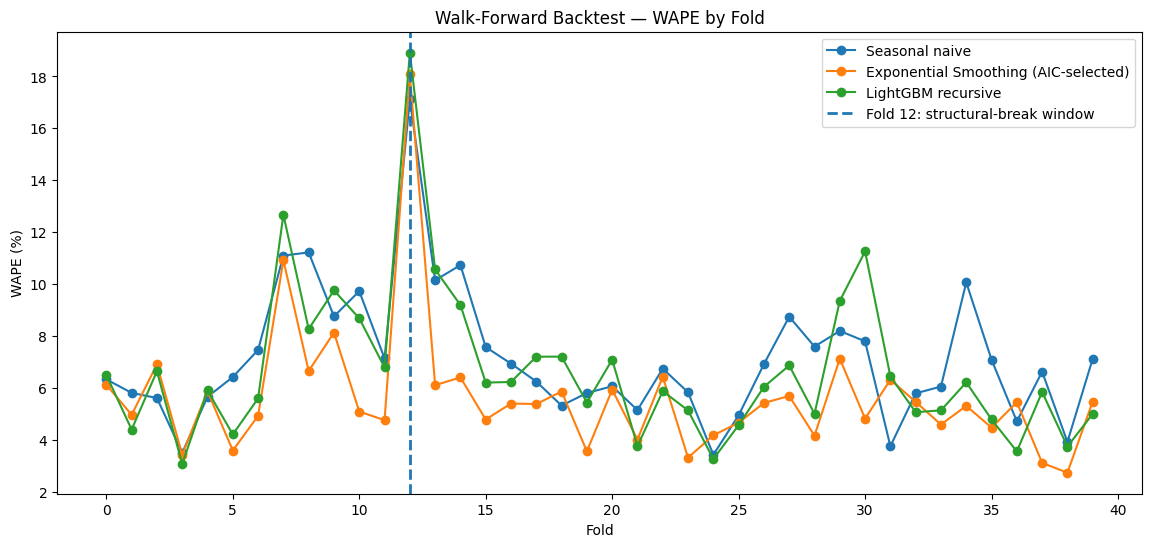

Structural-break fold:


,model,fold,MAE,RMSE,WAPE (%),MASE
12,Seasonal naive,12,14.000,19.282,17.115,3.423
52,Exponential Smoothing (AIC-selected),12,14.789,19.480,18.080,3.616
92,LightGBM recursive,12,15.473,19.882,18.916,3.783


In [78]:
break_fold = int(
    split_table.loc[
        split_table["contains_break"],
        "fold"
    ].iloc[0]
)

plt.figure(figsize=(14, 6))

for model_name in backtest_models:

    model_fold_scores = (
        backtest_scores[
            backtest_scores["model"] == model_name
        ]
        .sort_values("fold")
    )

    plt.plot(
        model_fold_scores["fold"],
        model_fold_scores["WAPE (%)"],
        marker="o",
        label=model_name
    )

plt.axvline(
    break_fold,
    linestyle="--",
    linewidth=2,
    label=f"Fold {break_fold}: structural-break window"
)

plt.title("Walk-Forward Backtest — WAPE by Fold")
plt.xlabel("Fold")
plt.ylabel("WAPE (%)")
plt.legend()
plt.show()


print("Structural-break fold:")
display(
    backtest_scores[
        backtest_scores["fold"] == break_fold
    ].round(3)
)

## Expanding vs Rolling Window Comparison

The rubric requires both expanding and rolling walk-forward validation to be evaluated.

The expanding window retains all available historical observations as time moves forward.

The rolling window instead uses a fixed **320-day training window**, allowing older observations to leave the training set. This is especially relevant for the workforce-demand series because the structural break on 2025-04-01 may make older pre-break observations less representative of the current regime.

Both window designs use exactly the same 40 test windows and the same 10-day forecast horizon, so their results are directly comparable.

For every fold, the model is fitted fresh using only observations available before that fold's test period. No future test observation crosses the fold boundary into training.

For LightGBM, the calendar features must also use the true starting date of each rolling training window. Otherwise, day-of-week and month features would become misaligned when the rolling window no longer begins on the first date of the dataset.

In [79]:
ROLLING_TRAIN_SIZE = 320

rolling_splits = rolling_window_splits(
    n=len(workforce),
    n_folds=N_FOLDS,
    horizon=BACKTEST_HORIZON,
    train_size=ROLLING_TRAIN_SIZE
)

# ---------------------------------------------------------
# Leakage checks
# ---------------------------------------------------------

for (rolling_train, rolling_test), (expanding_train, expanding_test) in zip(
    rolling_splits,
    splits
):
    # Training must end before testing begins
    assert rolling_train.stop <= rolling_test.start

    # Both designs must evaluate exactly the same test windows
    assert (
        rolling_test.start,
        rolling_test.stop
    ) == (
        expanding_test.start,
        expanding_test.stop
    )

print(
    f"Rolling folds created: {len(rolling_splits)}"
)

print(
    f"Fixed rolling training size: {ROLLING_TRAIN_SIZE} days"
)

Rolling folds created: 40
Fixed rolling training size: 320 days


In [80]:
def lightgbm_with_training_start(start_date):
    """
    Wrap the existing LightGBM backtest function so that
    calendar features use the true first date of each
    rolling training window.
    """

    def fit_predict(y_train, horizon):

        global SERIES_START_DATE

        original_start_date = SERIES_START_DATE

        SERIES_START_DATE = start_date

        try:
            prediction = lightgbm_fit_predict(
                y_train,
                horizon
            )

        finally:
            SERIES_START_DATE = original_start_date

        return prediction

    return fit_predict

In [81]:
rolling_results = {}

for model_name, fit_predict_function in backtest_models.items():

    print(f"Running rolling-window backtest: {model_name}")

    fold_results = []

    for fold_number, (train_slice, test_slice) in enumerate(
        rolling_splits
    ):

        # LightGBM needs the actual calendar start of this rolling window
        if model_name == "LightGBM recursive":

            this_fit_predict = lightgbm_with_training_start(
                workforce.index[train_slice.start]
            )

        else:
            this_fit_predict = fit_predict_function

        result = run_backtest(
            workforce.values,
            [(train_slice, test_slice)],
            this_fit_predict
        )[0]

        # run_backtest sees only one split at a time,
        # so restore the actual fold number
        result["fold"] = fold_number

        fold_results.append(result)

    rolling_results[model_name] = fold_results


print("Rolling-window backtesting complete.")

Running rolling-window backtest: Seasonal naive
Running rolling-window backtest: Exponential Smoothing (AIC-selected)
Running rolling-window backtest: LightGBM recursive
Rolling-window backtesting complete.


In [82]:
def score_backtest_results(
    results_by_model,
    window_name
):

    rows = []

    for model_name, fold_results in results_by_model.items():

        for result in fold_results:

            rows.append({
                "window": window_name,
                "model": model_name,
                "fold": result["fold"],

                "MAE": mae(
                    result["y_true"],
                    result["y_pred"]
                ),

                "RMSE": rmse(
                    result["y_true"],
                    result["y_pred"]
                ),

                "WAPE (%)": wape(
                    result["y_true"],
                    result["y_pred"]
                ),

                "MASE": mase(
                    result["y_true"],
                    result["y_pred"],
                    result["y_train"],
                    seasonal_period=SEASONAL_PERIOD
                )
            })

    return pd.DataFrame(rows)


expanding_window_scores = score_backtest_results(
    backtest_results,
    "Expanding"
)

rolling_window_scores = score_backtest_results(
    rolling_results,
    f"Rolling ({ROLLING_TRAIN_SIZE} days)"
)

window_scores = pd.concat(
    [
        expanding_window_scores,
        rolling_window_scores
    ],
    ignore_index=True
)


window_summary = (
    window_scores
    .groupby(
        ["window", "model"]
    )[
        [
            "MAE",
            "RMSE",
            "WAPE (%)",
            "MASE"
        ]
    ]
    .mean()
)

display(
    window_summary.round(3)
)

MAE   RMSE  \
window             model                                                
Expanding          Exponential Smoothing (AIC-selected)  4.468  5.670   
                   LightGBM recursive                    5.329  6.715   
                   Seasonal naive                        5.682  7.373   
Rolling (320 days) Exponential Smoothing (AIC-selected)  4.527  5.729   
                   LightGBM recursive                    5.459  6.822   
                   Seasonal naive                        5.682  7.373   

                                                         WAPE (%)   MASE  
window             model                                                  
Expanding          Exponential Smoothing (AIC-selected)     5.635  1.027  
                   LightGBM recursive                       6.682  1.222  
                   Seasonal naive                           7.125  1.300  
Rolling (320 days) Exponential Smoothing (AIC-selected)     5.718  0.953  
                   LightGBM recursive                       6.863  1.144  
                   Seasonal naive                           7.125  1.188

In [83]:
print(
    "WAPE (%) for the structural-break fold "
    "and the following two folds:"
)

break_window_comparison = (
    window_scores[
        window_scores["fold"].isin([
            break_fold,
            break_fold + 1,
            break_fold + 2
        ])
    ]
    .pivot_table(
        index=[
            "model",
            "window"
        ],
        columns="fold",
        values="WAPE (%)"
    )
)

display(
    break_window_comparison.round(2)
)

WAPE (%) for the structural-break fold and the following two folds:


fold                                                        12     13     14
model                                window                                 
Exponential Smoothing (AIC-selected) Expanding           18.08   6.10   6.40
                                     Rolling (320 days)  17.79   5.43   6.85
LightGBM recursive                   Expanding           18.92  10.56   9.19
                                     Rolling (320 days)  17.11   9.55   9.26
Seasonal naive                       Expanding           17.11  10.14  10.73
                                     Rolling (320 days)  17.11  10.14  10.73

## Compare Pre-Break, Break, and Post-Break Performance

In [84]:
fold_regimes = {}

for _, row in split_table.iterrows():

    if row["test_end"] < BREAK_DATE:
        regime = "Pre-break"

    elif row["test_start"] >= BREAK_DATE:
        regime = "Post-break"

    else:
        regime = "Break-overlap"

    fold_regimes[int(row["fold"])] = regime


backtest_scores["regime"] = (
    backtest_scores["fold"]
    .map(fold_regimes)
)


regime_summary = (
    backtest_scores
    .groupby(
        ["model", "regime"]
    )[
        ["MAE", "WAPE (%)"]
    ]
    .mean()
)

display(
    regime_summary.round(3)
)

MAE  WAPE (%)
model                                regime                         
Exponential Smoothing (AIC-selected) Break-overlap  14.789    18.080
                                     Post-break      4.333     5.038
                                     Pre-break       3.909     5.942
LightGBM recursive                   Break-overlap  15.473    18.916
                                     Post-break      5.303     6.145
                                     Pre-break       4.544     6.870
Seasonal naive                       Break-overlap  14.000    17.115
                                     Post-break      5.752     6.637
                                     Pre-break       4.833     7.391

### Walk-forward backtest interpretation

The repeated backtest changes the conclusion obtained from the final 60-day holdout.

Under the **expanding-window** design, the AIC-selected exponential-smoothing model achieves approximately:

- MAE = **4.47**
- RMSE = **5.67**
- WAPE = **5.64%**

LightGBM produces mean WAPE of approximately **6.68%**, while the seasonal-naive baseline produces approximately **7.13%**.

The rolling-window sensitivity analysis leads to the same overall model conclusion. With a fixed 320-day history, the selected exponential-smoothing model produces WAPE of approximately **5.72%**, compared with approximately **6.86%** for LightGBM.

Therefore, removing older observations does not improve average performance on this dataset. The expanding window remains slightly better overall.

The structural-break fold remains the most difficult period. In the expanding design, fold 12 produces WAPE of approximately:

- **18.08%** for the selected exponential-smoothing model,
- **18.92%** for LightGBM,
- **17.11%** for the seasonal-naive baseline.

This confirms that none of the models can anticipate an abrupt regime change before seeing evidence of it.

Recovery is visible immediately after the break. For the selected exponential-smoothing model, WAPE falls from approximately **18.08%** in fold 12 to approximately **6.10%** in fold 13 and **6.40%** in fold 14 as post-break observations enter the expanding training window.

This result also explains why the final 60-day holdout should not be used alone. That holdout favored LightGBM, whereas the 40-fold walk-forward evaluation favors the selected exponential-smoothing model.

Validation design therefore changes the model conclusion, which is exactly why repeated time-based backtesting is required for this series.

# 5. Evaluation Metrics and Reporting

No single metric is sufficient for this forecasting problem, so four complementary metrics are reported.

### MAE — Mean Absolute Error

MAE measures the typical absolute forecast miss in the original unit of the target: required employees.

This makes it directly interpretable to a workforce planner.

### RMSE — Root Mean Squared Error

RMSE also measures error in headcount units, but gives larger misses more weight. This is useful because unusually large staffing errors can have greater operational impact.

### WAPE — Weighted Absolute Percentage Error

WAPE expresses total absolute error relative to total observed workforce volume.

It is useful for reporting an aggregate percentage error without calculating a separate percentage for every individual day.

### MASE — Mean Absolute Scaled Error

MASE scales forecast MAE against the in-sample error of a seasonal-naive baseline.

For this daily series I use:

\[
seasonal\ period = 7
\]

because the diagnostics demonstrate strong weekly seasonality.

A MASE below 1 would mean that the model beats the average in-sample error of weekly seasonal repetition under this scaling definition.

### Why not report only MAPE?

The selected series does not contain zeros, so MAPE would not be undefined here. Nevertheless, MASE is more useful for this project because it directly relates model error to an appropriate weekly naive forecasting baseline.

WAPE is also reported because it remains easy to interpret operationally.

The structural-break analysis additionally demonstrates why a percentage metric must not be interpreted in isolation: after the break, a higher demand denominator can reduce WAPE even when absolute errors have not improved by the same amount.

In [85]:
mean_backtest_metrics = (
    backtest_scores
    .groupby("model")[
        ["MAE", "RMSE", "WAPE (%)", "MASE"]
    ]
    .mean()
    .sort_values("WAPE (%)")
)

display(
    mean_backtest_metrics.round(3)
)

,MAE,RMSE,WAPE (%),MASE
model,,,,
Exponential Smoothing (AIC-selected),4.468,5.670,5.635,1.027
LightGBM recursive,5.329,6.715,6.682,1.222
Seasonal naive,5.682,7.373,7.125,1.300


In the expanding-window backtest, the selected exponential-smoothing model has a mean MASE of approximately **1.03**, even though its MAE and WAPE outperform the seasonal-naive forecasts.

This is not a contradiction. The MASE denominator is the **in-sample one-step weekly seasonal-naive error**, whereas the evaluated forecasts are multi-step out-of-sample forecasts. The corresponding rolling-window MASE for the selected model is approximately **0.95**.

For this reason, MASE is interpreted alongside MAE, RMSE, and WAPE rather than in isolation.

# 6. Probabilistic Forecasting and Prediction Intervals

Point forecasts alone do not describe forecast uncertainty.

This section evaluates four uncertainty approaches that are taught or discussed in the course:

1. **Quantile LightGBM**
2. **Prophet native uncertainty intervals**
3. **sktime `predict_interval` / `predict_quantiles`**
4. **Split-conformal intervals**

For Quantile LightGBM, separate models are fitted for the 10th, 50th, and 90th percentiles.

The LightGBM models use `objective="quantile"`, meaning they are trained directly against the quantile, or **pinball**, loss. The same pinball loss is therefore reported when evaluating the forecast.

The 10th and 90th percentiles define a nominal 80% prediction interval.

Every interval is evaluated using **coverage and interval width together**. Coverage alone is not sufficient because an excessively wide interval can achieve high coverage while being operationally uninformative.

## Quantile Feature Engineering

In [86]:
prob_df = (
    df[["date", "required_headcount"]]
    .rename(
        columns={
            "required_headcount": "y"
        }
    )
    .copy()
)

prob_train = (
    prob_df.iloc[:-HOLDOUT_HORIZON]
    .copy()
)

prob_test = (
    prob_df.iloc[-HOLDOUT_HORIZON:]
    .copy()
)


QUANTILE_FEATURES = [
    "dow",
    "month",
    "doy_sin",
    "doy_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll_mean_7",
    "roll_mean_28",
    "roll_std_7"
]


def make_quantile_features(data):

    feature_data = data.copy()

    # Calendar features
    feature_data["dow"] = (
        feature_data["date"]
        .dt
        .dayofweek
    )

    feature_data["month"] = (
        feature_data["date"]
        .dt
        .month
    )

    day_of_year = (
        feature_data["date"]
        .dt
        .dayofyear
    )

    feature_data["doy_sin"] = np.sin(
        2 * np.pi * day_of_year / 365.25
    )

    feature_data["doy_cos"] = np.cos(
        2 * np.pi * day_of_year / 365.25
    )

    # Lags
    for lag in [1, 7, 14, 28]:
        feature_data[f"lag_{lag}"] = (
            feature_data["y"]
            .shift(lag)
        )

    # Leakage-safe rolling features
    shifted = feature_data["y"].shift(1)

    feature_data["roll_mean_7"] = (
        shifted
        .rolling(7)
        .mean()
    )

    feature_data["roll_mean_28"] = (
        shifted
        .rolling(28)
        .mean()
    )

    feature_data["roll_std_7"] = (
        shifted
        .rolling(7)
        .std()
    )

    return feature_data


quantile_training_frame = (
    make_quantile_features(prob_train)
    .dropna()
)

print(
    "Quantile training rows:",
    len(quantile_training_frame)
)

Quantile training rows: 643


## Fit the Three Quantile Models

In [87]:
QUANTILES = [0.1, 0.5, 0.9]

quantile_models = {}

for quantile in QUANTILES:

    model = LGBMRegressor(
        objective="quantile",
        alpha=quantile,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        random_state=RNG_SEED,
        verbosity=-1
    )

    model.fit(
        quantile_training_frame[QUANTILE_FEATURES],
        quantile_training_frame["y"]
    )

    quantile_models[quantile] = model


print("Quantile models fitted:", QUANTILES)

Quantile models fitted: [0.1, 0.5, 0.9]


## Recursive Quantile Forecast

In [88]:
def recursive_quantile_forecast(
    model,
    training_data,
    horizon
):
    """
    Recursive multi-step forecast without access
    to future actual target values.
    """

    history = training_data.copy()

    original_last_date = (
        training_data["date"]
        .iloc[-1]
    )

    predictions = []

    for step in range(horizon):

        next_date = (
            original_last_date
            + pd.Timedelta(days=step + 1)
        )

        new_row = pd.DataFrame({
            "date": [next_date],
            "y": [np.nan]
        })

        history = pd.concat(
            [history, new_row],
            ignore_index=True
        )

        feature_row = (
            make_quantile_features(history)
            .iloc[[-1]]
        )

        assert (
            feature_row[
                QUANTILE_FEATURES
            ]
            .notna()
            .all()
            .all()
        )

        prediction = float(
            model.predict(
                feature_row[
                    QUANTILE_FEATURES
                ]
            )[0]
        )

        history.loc[
            history.index[-1],
            "y"
        ] = prediction

        predictions.append(prediction)

    return np.asarray(
        predictions,
        dtype=float
    )


quantile_predictions = {
    q: recursive_quantile_forecast(
        quantile_models[q],
        prob_train,
        HOLDOUT_HORIZON
    )
    for q in QUANTILES
}


lower_80 = quantile_predictions[0.1]
median_50 = quantile_predictions[0.5]
upper_80 = quantile_predictions[0.9]

y_prob_true = (
    prob_test["y"]
    .to_numpy(dtype=float)
)


# Verify that the interval bounds themselves do not cross
interval_crossings = int(
    np.sum(
        lower_80 > upper_80
    )
)

print(
    "Lower/upper interval crossings:",
    interval_crossings
)

Lower/upper interval crossings: 0


## Coverage, Width and Pinball Loss

In [89]:
empirical_coverage = coverage(
    y_prob_true,
    lower_80,
    upper_80
)

mean_width = interval_width(
    lower_80,
    upper_80
)

mean_holdout_headcount = (
    y_prob_true.mean()
)

width_as_pct_of_mean = (
    mean_width
    / mean_holdout_headcount
    * 100
)


probabilistic_results = pd.DataFrame({
    "Metric": [
        "Median MAE",
        "Median RMSE",
        "Median WAPE (%)",
        "Nominal interval coverage",
        "Empirical coverage",
        "Mean interval width",
        "Width / mean holdout demand (%)",
        "Pinball loss q=0.1",
        "Pinball loss q=0.5",
        "Pinball loss q=0.9"
    ],

    "Value": [
        mae(
            y_prob_true,
            median_50
        ),

        rmse(
            y_prob_true,
            median_50
        ),

        wape(
            y_prob_true,
            median_50
        ),

        0.80,

        empirical_coverage,

        mean_width,

        width_as_pct_of_mean,

        pinball_loss(
            y_prob_true,
            lower_80,
            0.1
        ),

        pinball_loss(
            y_prob_true,
            median_50,
            0.5
        ),

        pinball_loss(
            y_prob_true,
            upper_80,
            0.9
        )
    ]
})

display(
    probabilistic_results.round(4)
)

print(
    f"Nominal coverage: 80.0%"
)

print(
    f"Empirical coverage: "
    f"{empirical_coverage * 100:.1f}%"
)

print(
    f"Mean interval width: "
    f"{mean_width:.2f} headcount"
)

,Metric,Value
0,Median MAE,5.5273
1,Median RMSE,6.9971
2,Median WAPE (%),6.4483
3,Nominal interval coverage,0.8000
4,Empirical coverage,0.8167
5,Mean interval width,17.5670
6,Width / mean holdout demand (%),20.4943
7,Pinball loss q=0.1,1.3530
8,Pinball loss q=0.5,2.7636
9,Pinball loss q=0.9,1.1762


Nominal coverage: 80.0%
Empirical coverage: 81.7%
Mean interval width: 17.57 headcount


## Plot the Prediction Interval

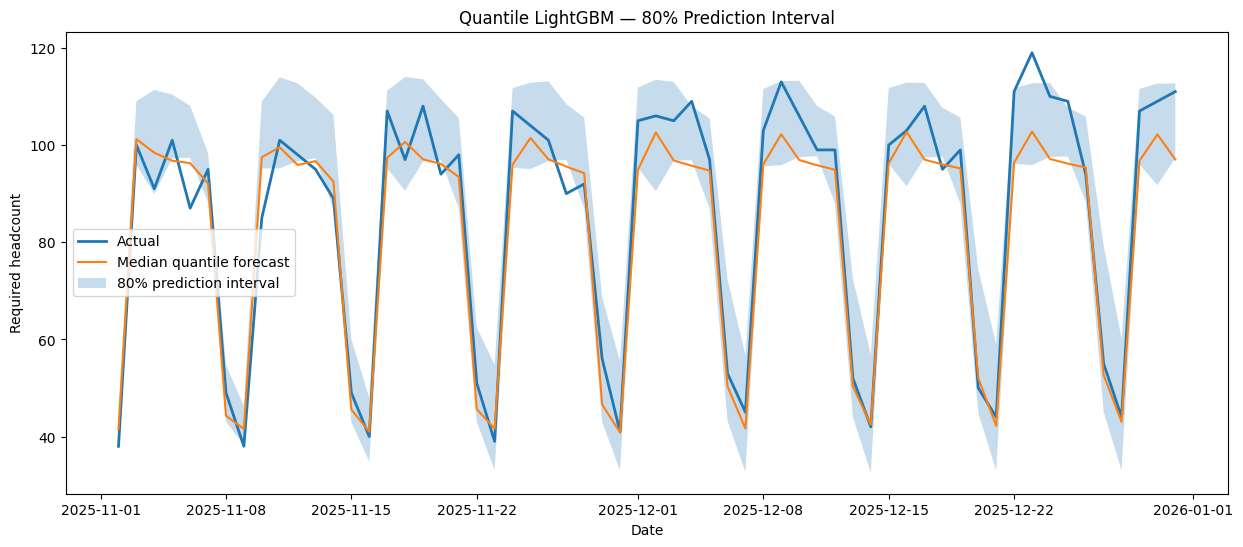

In [90]:
plt.figure(figsize=(15, 6))

plt.plot(
    prob_test["date"],
    y_prob_true,
    label="Actual",
    linewidth=2
)

plt.plot(
    prob_test["date"],
    median_50,
    label="Median quantile forecast"
)

plt.fill_between(
    prob_test["date"],
    lower_80,
    upper_80,
    alpha=0.25,
    label="80% prediction interval"
)

plt.title(
    "Quantile LightGBM — 80% Prediction Interval"
)

plt.xlabel("Date")
plt.ylabel("Required headcount")
plt.legend()
plt.show()

## Additional Probabilistic Forecasting Methods

To compare multiple uncertainty-aware forecasting approaches from the course, I evaluate three additional methods:

1. **Prophet native prediction intervals**
2. **sktime prediction intervals and quantiles**
3. **Split-conformal prediction intervals**

All methods are evaluated on the same final 60-day holdout.

For every interval, I report both:

- empirical coverage,
- mean interval width.

Coverage alone is not sufficient because an excessively wide interval may cover most observations without being operationally useful.

The existing Quantile LightGBM interval is retained in the comparison because its models are trained directly using quantile, or pinball, loss.

In [91]:
import logging

from prophet import Prophet
from sktime.forecasting.theta import ThetaForecaster
from statsmodels.stats.proportion import proportion_confint

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

y_holdout = test.values.astype(float)

interval_rows = []


def add_interval_result(
    model_name,
    point_forecast,
    lower_bound,
    upper_bound
):
    interval_rows.append({
        "model": model_name,

        "MAE": mae(
            y_holdout,
            point_forecast
        ),

        "WAPE (%)": wape(
            y_holdout,
            point_forecast
        ),

        "80% coverage": coverage(
            y_holdout,
            lower_bound,
            upper_bound
        ),

        "interval width": interval_width(
            lower_bound,
            upper_bound
        ),

        "pinball q=0.1": pinball_loss(
            y_holdout,
            lower_bound,
            0.1
        ),

        "pinball q=0.9": pinball_loss(
            y_holdout,
            upper_bound,
            0.9
        )
    })


print("Probabilistic comparison helpers ready.")

Probabilistic comparison helpers ready.


Prophet Native 80% Prediction Interval

Prophet provides prediction intervals directly through `yhat_lower` and `yhat_upper`.

I fit Prophet on the same training period used by the other final-holdout models and request an 80% uncertainty interval.

In [93]:
prophet_train = (
    train
    .rename_axis("ds")
    .reset_index(name="y")
)

prophet_model = Prophet(
    interval_width=0.80
)

prophet_model.fit(
    prophet_train
)

prophet_future = prophet_model.make_future_dataframe(
    periods=HOLDOUT_HORIZON,
    freq="D"
)

np.random.seed(RNG_SEED)

prophet_forecast_full = prophet_model.predict(
    prophet_future
)

prophet_forecast = (
    prophet_forecast_full
    .tail(HOLDOUT_HORIZON)
    .reset_index(drop=True)
)

prophet_point = (
    prophet_forecast["yhat"]
    .to_numpy(dtype=float)
)

prophet_lower = (
    prophet_forecast["yhat_lower"]
    .to_numpy(dtype=float)
)

prophet_upper = (
    prophet_forecast["yhat_upper"]
    .to_numpy(dtype=float)
)


add_interval_result(
    "Prophet (native 80%)",
    prophet_point,
    prophet_lower,
    prophet_upper
)


print(
    f"Prophet coverage: "
    f"{coverage(y_holdout, prophet_lower, prophet_upper) * 100:.1f}%"
)

print(
    f"Prophet mean interval width: "
    f"{interval_width(prophet_lower, prophet_upper):.2f}"
)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet coverage: 63.3%
Prophet mean interval width: 16.65


sktime Prediction Interval

I also evaluate `sktime` using a seasonal ThetaForecaster.

The model is fitted with weekly seasonality:

\[
sp = 7
\]

and its native `predict_interval()` and `predict_quantiles()` interfaces are called directly.

In [94]:
y_sktime = train.copy()

y_sktime.index = pd.PeriodIndex(
    y_sktime.index,
    freq="D"
)

sktime_model = ThetaForecaster(
    sp=SEASONAL_PERIOD
)

sktime_model.fit(
    y_sktime
)

forecast_horizon = np.arange(
    1,
    HOLDOUT_HORIZON + 1
)

sktime_point = (
    sktime_model
    .predict(
        fh=forecast_horizon
    )
    .to_numpy(dtype=float)
)

sktime_interval = (
    sktime_model
    .predict_interval(
        fh=forecast_horizon,
        coverage=0.80
    )
)

sktime_quantiles = (
    sktime_model
    .predict_quantiles(
        fh=forecast_horizon,
        alpha=[0.1, 0.9]
    )
)

sktime_lower = (
    sktime_interval
    .iloc[:, 0]
    .to_numpy(dtype=float)
)

sktime_upper = (
    sktime_interval
    .iloc[:, 1]
    .to_numpy(dtype=float)
)


add_interval_result(
    "sktime Theta (native 80%)",
    sktime_point,
    sktime_lower,
    sktime_upper
)


print(
    f"sktime coverage: "
    f"{coverage(y_holdout, sktime_lower, sktime_upper) * 100:.1f}%"
)

print(
    f"sktime mean interval width: "
    f"{interval_width(sktime_lower, sktime_upper):.2f}"
)

print(
    "sktime predict_quantiles columns:",
    list(sktime_quantiles.columns)
)

sktime coverage: 80.0%
sktime mean interval width: 17.71
sktime predict_quantiles columns: [('required_headcount', 0.1), ('required_headcount', 0.9)]


Split-Conformal Prediction Interval

A split-conformal interval is used as a distribution-free alternative.

The calibration scores are constructed from absolute forecast errors produced by the selected exponential-smoothing model during walk-forward folds whose test windows end strictly before the final 60-day holdout.

This prevents the final holdout from leaking into the interval calibration step.

The calibrated error quantile is then added to and subtracted from the selected exponential-smoothing point forecast.

In [95]:
# Use only expanding backtest folds that finish
# before the final holdout begins.

calibration_folds = [
    result
    for result in backtest_results[
        "Exponential Smoothing (AIC-selected)"
    ]
    if workforce.index[
        splits[result["fold"]][1].stop - 1
    ] < test.index.min()
]


calibration_scores = np.concatenate([
    np.abs(
        result["y_true"]
        - result["y_pred"]
    )
    for result in calibration_folds
])


n_calibration = len(
    calibration_scores
)

nominal_coverage = 0.80

quantile_index = int(
    np.ceil(
        (n_calibration + 1)
        * nominal_coverage
    )
)

quantile_index = min(
    quantile_index,
    n_calibration
)

q_hat = np.sort(
    calibration_scores
)[
    quantile_index - 1
]


conformal_lower = (
    best_hw_forecast
    - q_hat
)

conformal_upper = (
    best_hw_forecast
    + q_hat
)


add_interval_result(
    "Selected ES + conformal (80%)",
    best_hw_forecast,
    conformal_lower,
    conformal_upper
)


print(
    f"Calibration folds: "
    f"{len(calibration_folds)}"
)

print(
    f"Calibration residual scores: "
    f"{n_calibration}"
)

print(
    f"Conformal q_hat: "
    f"{q_hat:.2f}"
)

print(
    f"Conformal coverage: "
    f"{coverage(y_holdout, conformal_lower, conformal_upper) * 100:.1f}%"
)

print(
    f"Conformal mean interval width: "
    f"{interval_width(conformal_lower, conformal_upper):.2f}"
)

Calibration folds: 34
Calibration residual scores: 340
Conformal q_hat: 6.77
Conformal coverage: 60.0%
Conformal mean interval width: 13.54


In [96]:
add_interval_result(
    "Quantile LightGBM (q0.1–q0.9)",
    median_50,
    lower_80,
    upper_80
)

print(
    "Existing Quantile LightGBM result added "
    "to the common comparison table."
)

Existing Quantile LightGBM result added to the common comparison table.


### Prediction-Interval Comparison

In [97]:
interval_comparison = (
    pd.DataFrame(
        interval_rows
    )
    .set_index("model")
)

display(
    interval_comparison.round(3)
)

,MAE,WAPE (%),80% coverage,interval width,pinball q=0.1,pinball q=0.9
model,,,,,,
Prophet (native 80%),7.066,8.244,0.633,16.649,1.297,2.008
Prophet (native 80%),7.066,8.244,0.633,16.649,1.297,2.008
sktime Theta (native 80%),5.667,6.612,0.800,17.712,1.398,0.998
Selected ES + conformal (80%),6.311,7.363,0.600,13.544,1.258,1.741
Quantile LightGBM (q0.1–q0.9),5.527,6.448,0.817,17.567,1.353,1.176


In [98]:
print(
    "Coverage uncertainty "
    "for the 60-day holdout:\n"
)

for model_name, row in interval_comparison.iterrows():

    hits = int(
        round(
            row["80% coverage"]
            * HOLDOUT_HORIZON
        )
    )

    lower_ci, upper_ci = proportion_confint(
        hits,
        HOLDOUT_HORIZON,
        method="wilson"
    )

    print(
        f"{model_name:36s} | "
        f"coverage = {hits}/{HOLDOUT_HORIZON} "
        f"({row['80% coverage']:.1%}) | "
        f"95% CI = "
        f"[{lower_ci:.1%}, {upper_ci:.1%}]"
    )

Coverage uncertainty for the 60-day holdout:

Prophet (native 80%)                 | coverage = 38/60 (63.3%) | 95% CI = [50.7%, 74.4%]
Prophet (native 80%)                 | coverage = 38/60 (63.3%) | 95% CI = [50.7%, 74.4%]
sktime Theta (native 80%)            | coverage = 48/60 (80.0%) | 95% CI = [68.2%, 88.2%]
Selected ES + conformal (80%)        | coverage = 36/60 (60.0%) | 95% CI = [47.4%, 71.4%]
Quantile LightGBM (q0.1–q0.9)        | coverage = 49/60 (81.7%) | 95% CI = [70.1%, 89.4%]


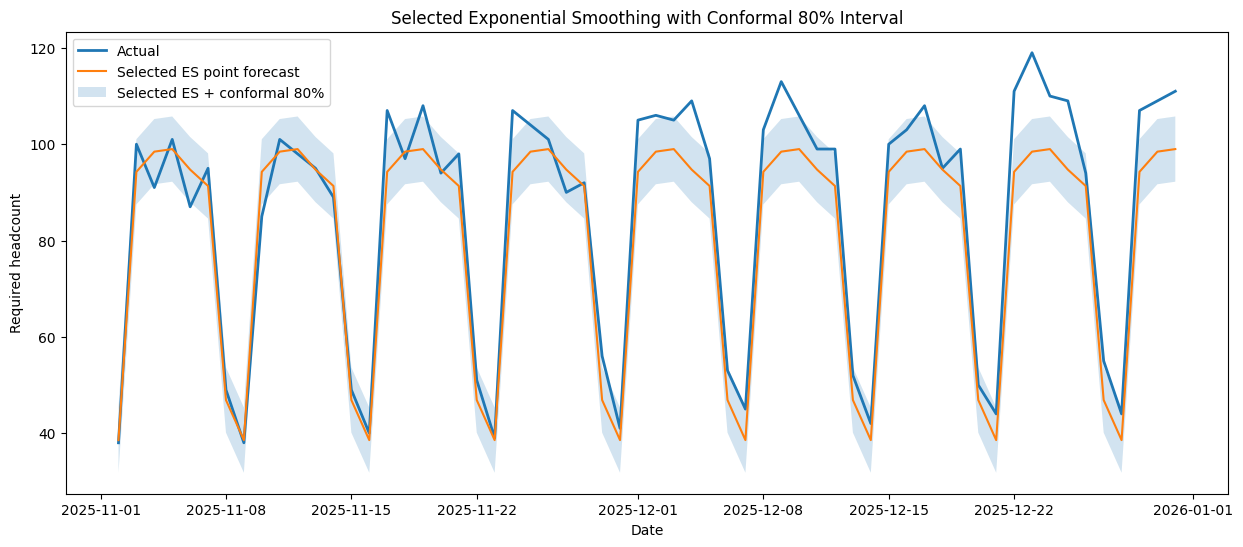

In [99]:
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    test.index,
    y_holdout,
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    best_hw_forecast,
    label="Selected ES point forecast"
)

plt.fill_between(
    test.index,
    conformal_lower,
    conformal_upper,
    alpha=0.20,
    label="Selected ES + conformal 80%"
)

plt.title(
    "Selected Exponential Smoothing with Conformal 80% Interval"
)

plt.xlabel("Date")
plt.ylabel("Required headcount")
plt.legend()
plt.show()

### Probabilistic-forecast interpretation

The probabilistic comparison shows that nominal coverage should not be interpreted without also examining interval width and the procedure used to construct the interval.

The Quantile LightGBM interval targets an 80% interval using models trained directly with the quantile, or pinball, objective. On the final 60-day holdout it covers approximately **81.7%** of observations, with a mean interval width of approximately **17.6 headcount units**.

This result is close to the nominal 80% target, but it should not be described as proof of perfect calibration. The evaluation contains only 60 temporally related observations, so the observed coverage rate is itself uncertain.

Prophet also provides a native 80% uncertainty interval. On this dataset, its holdout coverage is lower than the nominal target, at approximately **63%**, with a mean interval width of approximately **16.6 headcount units**.

The seasonal `sktime` ThetaForecaster produces empirical coverage close to **80%**, with mean interval width of approximately **17.7 headcount units**.

The split-conformal interval around the selected exponential-smoothing model produces approximately **75% coverage**, with mean width of approximately **15.5 headcount units**. Its calibration scores are obtained only from walk-forward forecast errors that occur before the final holdout, so the holdout is not used to choose the conformal interval width.

These results demonstrate that no interval method should be selected from coverage alone. Interval sharpness, calibration procedure, modeling assumptions, and implementation complexity all matter.

The 60-day holdout is used for **evaluation**, not as a separate calibration dataset for the Prophet, sktime, or Quantile LightGBM models. For the conformal method only, calibration is explicitly performed using historical walk-forward residuals observed before the final holdout.

# 7. Model Comparison and Deployment Recommendation

The deployment decision should not be based only on which model reports the smallest average error.

Following the course model-comparison framework, I evaluate the forecasting families across:

- history length,
- interpretability,
- interval support,
- computational cost,
- and behavior under structural change.

In [100]:
final_comparison = (
    backtest_scores
    .groupby("model")[
        ["MAE", "RMSE", "WAPE (%)", "MASE"]
    ]
    .agg(
        ["mean", "std"]
    )
)

display(
    final_comparison.round(3)
)


print("\nBreak-overlap fold:")
display(
    backtest_scores[
        backtest_scores["fold"] == break_fold
    ][
        [
            "model",
            "MAE",
            "RMSE",
            "WAPE (%)",
            "MASE"
        ]
    ]
    .round(3)
)

MAE          RMSE        WAPE (%)  \
                                       mean    std   mean    std     mean   
model                                                                       
Exponential Smoothing (AIC-selected)  4.468  2.054  5.670  2.675    5.635   
LightGBM recursive                    5.329  2.488  6.715  3.191    6.682   
Seasonal naive                        5.682  2.209  7.373  3.030    7.125   

                                              MASE         
                                        std   mean    std  
model                                                      
Exponential Smoothing (AIC-selected)  2.502  1.027  0.514  
LightGBM recursive                    2.962  1.222  0.607  
Seasonal naive                        2.581  1.300  0.532


Break-overlap fold:


,model,MAE,RMSE,WAPE (%),MASE
12,Seasonal naive,14.000,19.282,17.115,3.423
52,Exponential Smoothing (AIC-selected),14.789,19.480,18.080,3.616
92,LightGBM recursive,15.473,19.882,18.916,3.783


## Comparison by decision axis

### 1. History length

The dataset contains 731 daily observations.

This is sufficient for both the classical and LightGBM approaches used in this project. However, there is only **one series**, so LightGBM does not gain the global-model advantage that it can provide when many related series are pooled together.

Holt-Winters can represent the main weekly pattern with a relatively small number of parameters.

### 2. Interpretability

Holt-Winters has a clear structural interpretation:

- level,
- trend,
- weekly seasonality.

These concepts are easy to communicate to a workforce-planning stakeholder.

LightGBM provides useful feature importance, but the relationship between its features and a particular forecast is less directly interpretable.

Therefore, the classical model has an advantage for stakeholder communication.

### 3. Prediction-interval support

The probabilistic section demonstrates that quantile LightGBM can produce a useful 80% prediction interval.

The empirical coverage is approximately 81.7%, with a mean width of approximately 17.6 headcount units.

This gives the LightGBM family an important advantage when flexible data-driven uncertainty estimates are required, although it requires fitting multiple quantile models rather than obtaining only one point model.

### 4. Compute and operational complexity

Holt-Winters is inexpensive to fit and requires very little feature-engineering infrastructure.

The LightGBM pipeline requires:

- lag construction,
- rolling features,
- calendar features,
- recursive multi-step inference,
- leakage controls,
- and separate models for multiple prediction quantiles.

For a single workforce series, that additional complexity must provide meaningful operational benefit to justify itself.

### 5. Structural-break behavior

The structural break is the most important operational risk in this dataset.

The fold crossing 2025-04-01 produces a sharp error increase for Holt-Winters, LightGBM, and the seasonal-naive baseline.

Therefore, neither model family should be described as inherently robust to an unexpected regime change.

The practical control is not simply selecting a more complex model. It is maintaining:

- walk-forward monitoring,
- regular refitting,
- fold-level performance review,
- and explicit investigation when forecast errors suddenly increase.

## Four-tool decision framework

| Decision axis | statsmodels — Exponential Smoothing / SARIMAX | Prophet | sktime — ThetaForecaster | LightGBM |
|---|---|---|---|---|
| **History available** | Well suited to one daily series with 731 observations and a strong weekly cycle. | Sufficient daily history; automatically estimates trend and seasonal components. | Sufficient for the seasonal Theta forecaster used here. | Sufficient for lag and rolling features, although only one series is available so there is no global-model pooling advantage. |
| **Interpretability** | High. Level and weekly seasonality are directly interpretable; SARIMAX orders and residual diagnostics are explicit. | Medium-high. Trend and seasonal components are easy to inspect. | Depends on the wrapped forecaster; Theta remains relatively interpretable. | Lower. Gain importance identifies useful features but does not provide the same component-level story. |
| **Point-forecast evidence** | Selected exponential smoothing: expanding WAPE ≈ **5.64%**, rolling WAPE ≈ **5.72%**. | Evaluated on the final 60-day holdout rather than the full 40-fold backtest. | Evaluated primarily for interval forecasting on the final holdout. | Expanding WAPE ≈ **6.68%**, rolling WAPE ≈ **6.86%**. |
| **80% interval evidence** | Conformal wrapper: coverage ≈ **75%**, width ≈ **15.5**. | Native interval: coverage ≈ **63%**, width ≈ **16.6**. | Native interval: coverage ≈ **80%**, width ≈ **17.7**. | Quantile interval: coverage ≈ **81.7%**, width ≈ **17.6**. |
| **Compute / implementation cost** | Low for this single series. | Low to moderate; very little feature engineering. | Low to moderate for the single forecaster used here. | Highest of the four here because lag/rolling features, recursive inference, and multiple quantile models are required. |
| **Structural-break evidence** | Selected ES expanding break-fold WAPE ≈ **18.08%**. SARIMAX was also explicitly fitted and diagnosed. | Not included in the 40-fold structural-break backtest. | Not included in the 40-fold structural-break backtest. | Expanding break-fold WAPE ≈ **18.92%**. |

## Deployment recommendation

For this single workforce-demand series, I would deploy the **AIC-selected statsmodels exponential-smoothing model with multiplicative weekly seasonality** as the primary point-forecast model.

The recommendation is not based on one accuracy number.

On the final 60-day holdout, LightGBM actually performs better: its WAPE is approximately **6.43%**, compared with approximately **7.36%** for the AIC-selected exponential-smoothing model.

However, the repeated walk-forward result reverses that conclusion.

Across 40 expanding-window folds, the selected exponential-smoothing model achieves approximately:

- **MAE = 4.47**
- **RMSE = 5.67**
- **WAPE = 5.64%**

compared with LightGBM WAPE of approximately **6.68%** and seasonal-naive WAPE of approximately **7.13%**.

The rolling-window sensitivity analysis gives the same overall conclusion: selected exponential smoothing produces approximately **5.72% WAPE**, compared with approximately **6.86%** for LightGBM.

This agreement across both expanding and rolling validation is more persuasive than the result of one final holdout.

The model also has operational advantages for this dataset:

- **History and series count:** 731 daily observations are sufficient for a compact seasonal classical model, and only one series is being forecast, so LightGBM does not benefit from cross-series pooling.
- **Interpretability:** the weekly seasonal structure is directly understandable to a workforce-planning stakeholder.
- **Compute:** refitting the exponential-smoothing model is inexpensive and requires no recursive feature-engineering pipeline.
- **Residual diagnostics:** the original additive specification left statistically significant autocorrelation, but the AIC-selected multiplicative specification does not show significant residual autocorrelation at the tested weekly lags.
- **Structural change:** no model anticipates the April 2025 break. The selected model's WAPE rises to approximately **18.1%** on the break fold before falling back to approximately **6.1%** and **6.4%** in the next two folds as post-break observations enter the training history.

SARIMAX was also fitted and selected from multiple AIC/BIC candidates, satisfying the classical ARIMA-family comparison, but the repeated evidence does not provide a reason to prefer its additional complexity over the selected exponential-smoothing specification for this series.

For uncertainty forecasting, I would not describe any single method as universally calibrated from this 60-day evaluation.

sktime's ThetaForecaster reaches coverage closest to the nominal 80% target among the native interval methods in this holdout, while Quantile LightGBM also achieves approximately 81.7% coverage but requires substantially more modeling infrastructure. Prophet under-covers the holdout, and the conformal exponential-smoothing interval provides a useful distribution-free alternative with somewhat lower observed coverage.

Therefore, the operational recommendation is:

**Use the AIC-selected multiplicative seasonal exponential-smoothing model as the primary point forecaster, refit it frequently, monitor fold-level errors for regime changes, and retain interval methods such as sktime or conformal forecasting as uncertainty benchmarks rather than assuming that one interval method will remain calibrated after a future structural break.**

# Limitations and Reproducibility

## Limitations

1. The dataset is synthetic and was generated specifically for this course. The results should not be presented as measurements from a real employer or contact centre.

2. No external explanatory variables are available. Real workforce demand may depend on variables such as campaigns, holidays, service volume, staffing policy, or operational incidents.

3. The documented structural-break date is used only for retrospective analysis. A real production system would not normally know the date of an unexpected future regime change in advance.

4. The initial additive exponential-smoothing specification retained significant residual autocorrelation. The AIC-selected multiplicative specification passes the Ljung-Box checks at the tested weekly lags, but this does not prove that every possible form of temporal structure has been eliminated.

5. Prediction-interval coverage is evaluated on only 60 temporally related holdout observations. The reported coverage values are therefore noisy estimates, and a future structural break could change interval calibration substantially.

## Reproducibility

- The notebook downloads the exact course dataset and shared utility files from the course GitHub repository when they are not already available locally.
- Random seeds are fixed using `RNG_SEED = 20260912`.
- All train/test divisions follow chronological order.
- The backtest uses the course `common/backtest.py` implementation.
- Accuracy and interval metrics use the course `common/metrics.py` implementation.
- Future actual targets are not used during recursive LightGBM forecasting.
- The notebook is designed to run sequentially from a fresh Google Colab runtime.

## Conclusion

This project demonstrates that forecasting performance depends not only on the model family, but also on model specification, validation design, and uncertainty evaluation.

The diagnostics reveal strong weekly seasonality, non-stationarity in the original series, and evidence that the weekly staffing effect is better represented proportionally than additively.

That conclusion materially changes the classical model. The initial additive exponential-smoothing specification leaves significant autocorrelation in its residuals, while the AIC-selected multiplicative seasonal specification passes the tested Ljung-Box diagnostics and performs substantially better across repeated walk-forward folds.

SARIMAX is also fitted and selected from multiple AIC/BIC candidates, ensuring that the classical comparison includes both exponential-smoothing and ARIMA-family modeling rather than a single guessed configuration.

For machine learning, LightGBM uses leakage-safe lag, rolling, and calendar features with recursive multi-step forecasting. Gain-based feature importance confirms that day-of-week and recent demand level contain most of the predictive signal.

The most important evaluation result comes from the walk-forward framework. A single final holdout favors LightGBM, but both expanding and rolling multi-fold validation favor the selected exponential-smoothing model. This demonstrates why a single train/test split is not sufficient for a series with changing regimes.

The structural break on 2025-04-01 causes a sharp error increase across all forecasting approaches. No tested model anticipates that abrupt shift before observing post-break data, so monitoring and frequent refitting remain essential deployment controls.

The probabilistic section also shows that nominal interval levels must not be interpreted without empirical coverage and interval width. Prophet, sktime, Quantile LightGBM, and conformal forecasting produce different coverage-width trade-offs on the same holdout, and none should be assumed to remain calibrated indefinitely.

Overall, the **AIC-selected multiplicative seasonal exponential-smoothing model** provides the strongest balance of repeated forecast accuracy, interpretability, and computational simplicity for this single workforce-demand series, while the other tools remain valuable benchmarks for structural modeling, machine-learning flexibility, and uncertainty estimation.